**Predict students dropout and academic success**

### **Loading Dataset**

In [ ]:
path = "/content/dataset.csv"

In [ ]:
# Importing necessary libraries for data analysis and visualization

import numpy as np # Library for numerical computations
import pandas as pd # Library for data manipulation and analysis
import matplotlib.pyplot as plt # Library for plotting graphs and visualizations
import seaborn as sns # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder # Library for encoding categorical variables

# Suppressing warnings to prevent unnecessary output during execution

import warnings
warnings.simplefilter('ignore')

In [ ]:
data = pd.read_csv("/content/dataset.csv", sep = ';') # Reading the dataset CSV file into a Pandas DataFrame
data.head() # Displaying the first 5 rows of the dataset to get an overview of the data

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# Displaying the 'Target' column to understand what we're predicting (dropout or academic success)

data['Target']

,Target
0,Dropout
1,Graduate
2,Dropout
3,Graduate
4,Graduate
...,...
4419,Graduate
4420,Dropout
4421,Dropout
4422,Graduate


In [ ]:
data.drop('Target', axis=1, inplace=False).corr() # Dropping the 'Target' column from the DataFrame

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
Marital status,1.000000,0.264006,-0.125854,0.046365,-0.274939,0.062529,-0.022406,-0.008843,0.193163,0.130353,...,0.034711,0.062831,0.039026,0.022784,-0.043739,-0.071506,0.020426,-0.020338,0.008761,-0.027003
Application mode,0.264006,1.000000,-0.286357,0.065385,-0.304092,0.422411,-0.039020,-0.000661,0.118974,0.083276,...,0.045828,0.238445,0.130046,0.167872,-0.071526,-0.115424,0.047983,0.089080,-0.016375,-0.022743
Application order,-0.125854,-0.286357,1.000000,0.059507,0.158657,-0.184315,-0.064484,-0.022416,-0.064956,-0.050288,...,-0.031699,-0.125815,0.028878,-0.055089,0.071793,0.055517,-0.015757,-0.098419,-0.011133,0.030201
Course,0.046365,0.065385,0.059507,1.000000,-0.043151,0.006654,-0.081013,-0.033923,0.054543,0.050724,...,0.034514,-0.089817,0.401539,0.278797,0.198032,0.348728,0.030816,0.007153,0.017710,-0.020265
Daytime/evening attendance\t,-0.274939,-0.304092,0.158657,-0.043151,1.000000,-0.071871,0.052597,0.018530,-0.204767,-0.139894,...,0.045630,-0.111953,0.000371,0.014610,0.034022,0.050493,-0.004229,0.061974,-0.024043,0.022929
Previous qualification,0.062529,0.422411,-0.184315,0.006654,-0.071871,1.000000,0.104072,-0.029214,-0.013190,-0.006614,...,0.002887,0.143031,0.056179,0.114850,-0.008632,0.000942,0.005102,0.111958,-0.063736,0.064069
Previous qualification (grade),-0.022406,-0.039020,-0.064484,-0.081013,0.052597,0.104072,1.000000,0.054088,-0.060670,-0.035234,...,-0.003926,-0.018489,-0.031649,-0.061355,0.050263,0.053239,-0.019015,0.045222,0.018710,-0.052620
Nacionality,-0.008843,-0.000661,-0.022416,-0.033923,0.018530,-0.029214,0.054088,1.000000,-0.049946,-0.085282,...,0.009145,-0.007278,-0.020113,-0.025721,-0.017880,-0.008497,-0.014041,-0.000651,-0.008922,0.034478
Mother's qualification,0.193163,0.118974,-0.064956,0.054543,-0.204767,-0.013190,-0.060670,-0.049946,1.000000,0.535140,...,0.003183,0.042771,0.035150,0.021033,-0.014858,-0.031175,0.021305,-0.114351,0.059441,-0.083657
Father's qualification,0.130353,0.083276,-0.050288,0.050724,-0.139894,-0.006614,-0.035234,-0.085282,0.535140,1.000000,...,-0.017333,0.042666,0.024380,0.009514,0.005285,-0.008083,-0.007430,-0.077905,0.057633,-0.071610


In [ ]:
# Displaying a summary of the dataset, including the data types and non-null values for each column

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
# Define a class for loading and processing datasets

class DataLoader:
    def __init__(self, filepath):
        self.filepath = filepath # Initialize the class with the file path where the dataset is located
        self.df = None # Initialize the df attribute to None, will store the DataFrame after loading data

    def load_data(self):
        try:
            self.df = pd.read_csv(path) # Attempt to read the CSV file at the given path
            self.df.columns = self.df.columns.map(lambda x: x.replace(' ', '_')) # Replace spaces in column names with underscores for easier access

            print('Dataset loaded successfully!')
            print("Preview of the loaded dataset:")
            print(self.df.head())

        except FileNotFoundError:
            print(f"Error: The file at {self.filepath} was not found.") # If the file is not found, catch the exception and print an error message
        return self.df # Return the loaded DataFrame

data_loader = DataLoader(path) # Create an instance of the DataLoader class with the file path
df = data_loader.load_data() # Call the load_data method to load the data and store it in the df variable

Dataset loaded successfully!
Preview of the loaded dataset:
  Marital_status;Application_mode;Application_order;Course;"Daytime/evening_attendance\t";Previous_qualification;Previous_qualification_(grade);Nacionality;Mother's_qualification;Father's_qualification;Mother's_occupation;Father's_occupation;Admission_grade;Displaced;Educational_special_needs;Debtor;Tuition_fees_up_to_date;Gender;Scholarship_holder;Age_at_enrollment;International;Curricular_units_1st_sem_(credited);Curricular_units_1st_sem_(enrolled);Curricular_units_1st_sem_(evaluations);Curricular_units_1st_sem_(approved);Curricular_units_1st_sem_(grade);Curricular_units_1st_sem_(without_evaluations);Curricular_units_2nd_sem_(credited);Curricular_units_2nd_sem_(enrolled);Curricular_units_2nd_sem_(evaluations);Curricular_units_2nd_sem_(approved);Curricular_units_2nd_sem_(grade);Curricular_units_2nd_sem_(without_evaluations);Unemployment_rate;Inflation_rate;GDP;Target
0  1;17;5;171;1;1;122.0;1;19;12;5;9;127.3;1;0;0;1...       

### **Data Acquisition and Preparation**

In [ ]:
# Define a class for exploring and cleaning the dataset

class DataExplorer: # Initialize the class with the DataFrame to be explored
    def __init__(self, dataframe):
        self.df = dataframe

    # Method to return the shape (number of rows and columns) of the dataset
    def get_shape(self):
        return self.df.shape

    # Method to check for missing values in the dataset and return the count of missing values per column
    def check_missing_values(self):
        return self.df.isnull().sum()

    # Method to find and display duplicate rows in the datase
    def find_duplicates(self):
        duplicate = self.df[self.df.duplicated()] # Get rows that are duplicates of others
        print("Duplicate Rows:")
        return duplicate

    # Method to clean the column names by replacing spaces with underscores and removing apostrophes
    def clean_column_names(self):
        self.df.columns = [col.replace(' ', '_').replace("'", "") for col in self.df.columns] # Replace spaces with underscores and remove any apostrophes from column names

    # Method to display the first 5 rows of the dataset
    def display_head(self):
        return self.df.head()

    # Method to display the column names of the dataset
    def display_columns(self):
        return self.df.columns

data = pd.read_csv(path, sep=';') # Reading the dataset into a DataFrame
explorer = DataExplorer(data) # Create an instance of DataExplorer class to explore and clean the dataset

print("Dataset Shape:", explorer.get_shape())

print("Missing Values:")
print(explorer.check_missing_values())

# Find and display duplicate rows in the dataset
duplicate_rows = explorer.find_duplicates()
print(duplicate_rows)

print("Columns Before Cleaning:")
print(explorer.display_columns())

# Clean the column names by removing spaces and apostrophes
explorer.clean_column_names()

print("Columns After Cleaning:")
print(explorer.display_columns())

print("Preview of Dataset:")
print(explorer.display_head())

Dataset Shape: (4424, 37)
Missing Values:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder    


1. There is no missing values present in the dataset.
2. There is no duplicate rows present in the dataset.

### **Exploratory Data Analysis**

In [ ]:
# Define a class for analyzing the dataset

class DataAnalyzer: # Initialize the class with the dataset (DataFrame)
    def __init__(self, data):
        self.data = data # Store the dataset to be analyzed

    # Method to display general information about the dataset
    def display_info(self):
        self.data.info() # This provides a summary of the dataset, helping to understand its structure and quality

    # Method to display the counts of unique values in the 'Target' column
    def display_target_counts(self):
        if 'Target' in self.data.columns: # Check if the 'Target' column exists in the dataset
            return self.data['Target'].value_counts() # Return the count of unique values in the 'Target' column
        else:
            KeyError("'Target' column is not present in the dataset.") # If the 'Target' column does not exist, raise a KeyError

data = pd.read_csv(path, sep=';')
data_analyzer = DataAnalyzer(data) # Create an instance of DataAnalyzer with the loaded dataset

data_analyzer.display_info() # Display general information about the dataset

# Display the count of unique values in the 'Target' column
target_counts = data_analyzer.display_target_counts() # Provides insight into the distribution of the target variable
print(target_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

There are 7 floating point numbers, 29 integers and just 1 object column.

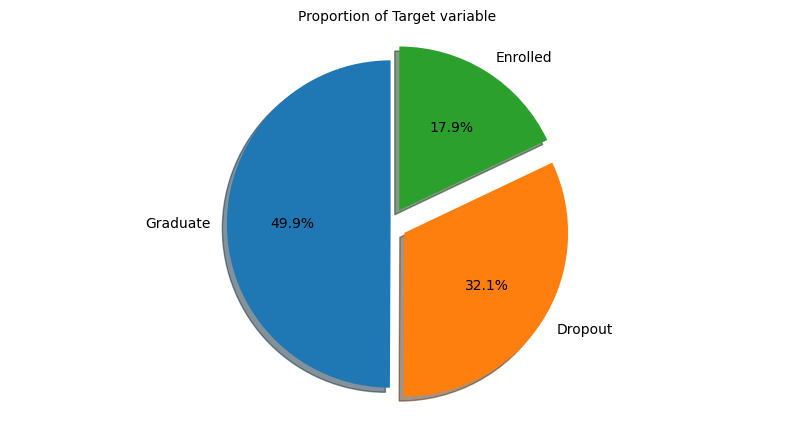

In [ ]:
# Define a class to visualize the distribution of the target variable using a pie chart

class TargetDistributionPlotter: # Initialize the class with the dataset and labels for the target variable
    def __init__(self, data):
        self.data = data # Store the dataset to be analyzed
        self.labels = ['Graduate', 'Dropout', 'Enrolled'] # Define the labels for the target categories
        self.explode = (0, 0.1, 0.1) # Create a slight "explode" effect to highlight the 'Dropout' and 'Enrolled' slices

    # Method to calculate the sizes (count of records) for each category in the 'Target' column
    def calculate_sizes(self):
        sizes = [
            self.data.Target[self.data['Target'] == label].count()  # Count records matching each label
            for label in self.labels
    ]
        return sizes # Return the list of counts for each label

    # Method to plot a pie chart visualizing the target variable distribution
    def plot_pie_chart(self):
        sizes = self.calculate_sizes() # Calculate the sizes for each label
        fig1, ax1 = plt.subplots(figsize=(10, 5)) # Create a new figure and axis for the plot

        # Plot the pie chart with the calculated sizes, labels, and explode effect
        ax1.pie(sizes, explode=self.explode, labels=self.labels, autopct='%1.1f%%',shadow=True, startangle=90) # Ensure the pie chart is circular (not elliptical)
        ax1.axis('equal') # Ensure the pie chart is circular
        plt.title("Proportion of Target variable", size=10) # Set a title for the pie chart
        plt.show()

plotter = TargetDistributionPlotter(data) # Create an instance of TargetDistributionPlotter with the dataset
plotter.plot_pie_chart() # Call the method to plot the pie chart of the target variable distribution


From above pie chart,we can see that around 49.9% of the students are graduate, 32.1% students are dropout, and 17.1% of the students are enrolled in some other course, which indicates that half of the students from the total population are grduate

In [ ]:
# Define a class to select numerical (continuous) variables from the dataset

class DataSelector: # Initialize the class with the dataset
    def __init__(self, data):
        self.data = data # Store the dataset to be processed

    # Method to select and return only the numerical columns (continuous variables)
    def select_numerical_columns(self):
        return self.data.select_dtypes(include=['float64']) # Use pandas' select_dtypes method to select columns of type 'float64', which are continuous variables

data_selector = DataSelector(data) # Create an instance of DataSelector with the dataset
data_num = data_selector.select_numerical_columns() #  Generate a DataFrame containing only the numerical columns (continuous variables)
print(data_num)

      Previous qualification (grade)  Admission grade  \
0                              122.0            127.3   
1                              160.0            142.5   
2                              122.0            124.8   
3                              122.0            119.6   
4                              100.0            141.5   
...                              ...              ...   
4419                           125.0            122.2   
4420                           120.0            119.0   
4421                           154.0            149.5   
4422                           180.0            153.8   
4423                           152.0            152.0   

      Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
0                             0.000000                          0.000000   
1                            14.000000                         13.666667   
2                             0.000000                          0.000000   
3          

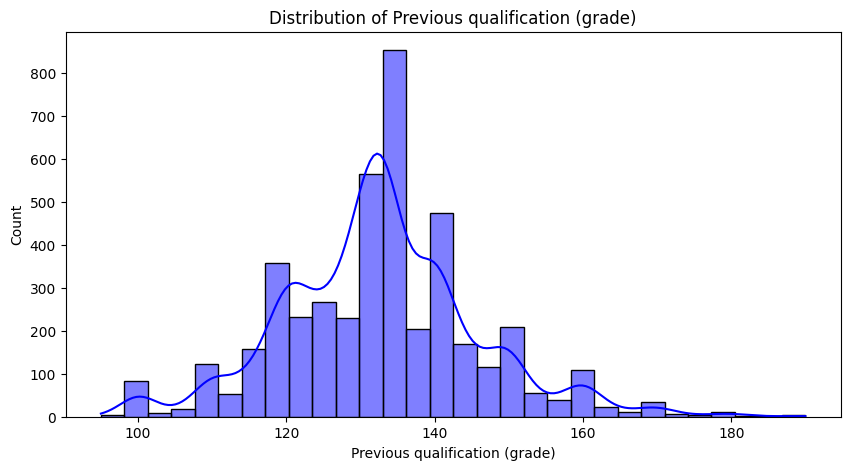

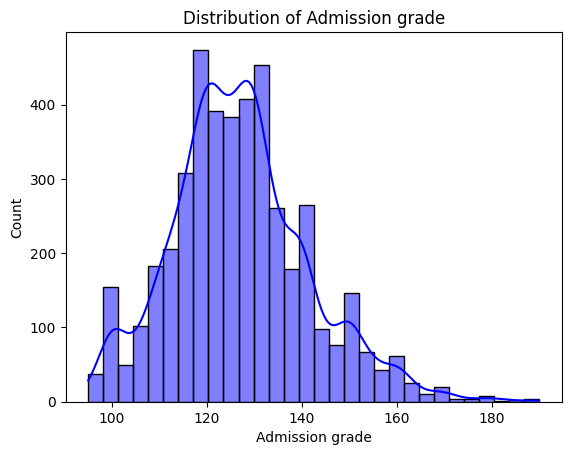

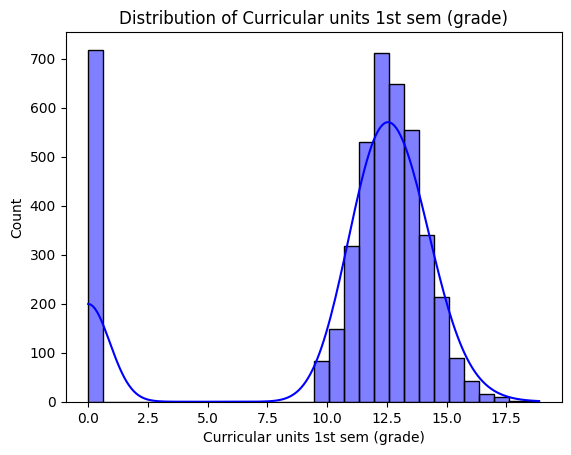

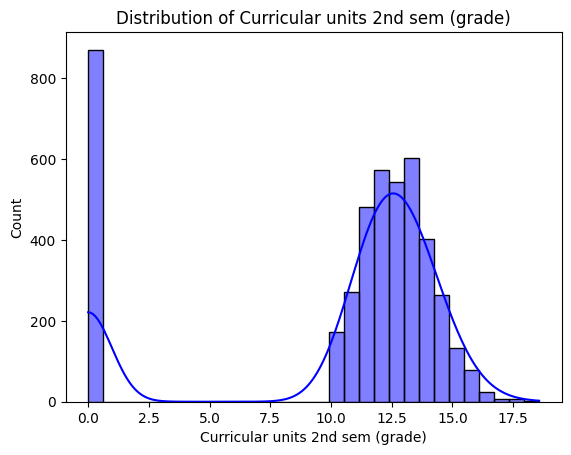

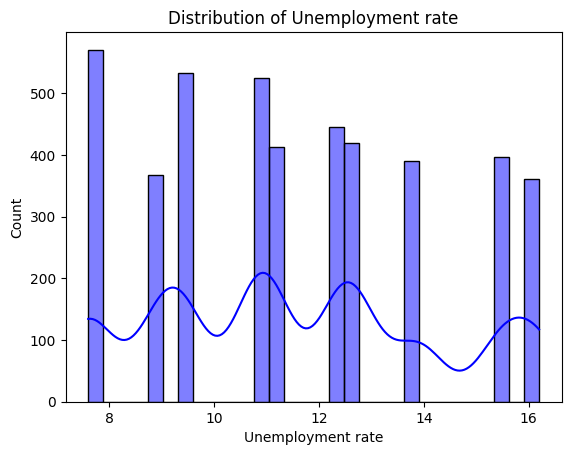

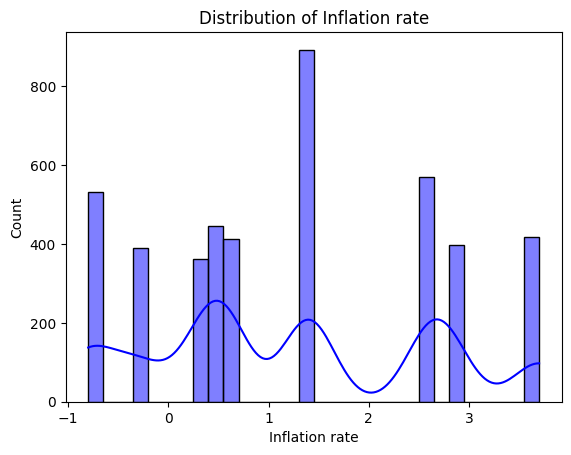

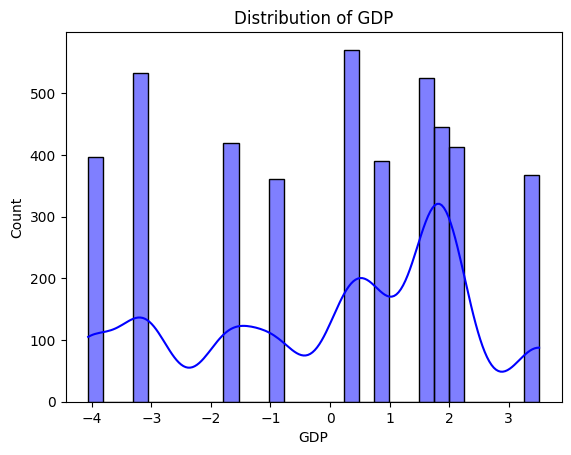

In [ ]:
# Define a class to plot the distribution of continuous variables in the dataset

class DistributionPlotter:
    def __init__(self, data): # Initialize the class with the dataset
        self.data = data # Store the dataset to be analyzed
        self.data_num = self.data.select_dtypes(include=['float64']) # Select only the numerical columns

    # Method to plot the distribution of each continuous variable
    def plot_distributions(self):
        plt.figure(figsize=(10, 5)) # Set the size of the figure to make the plots larger and easier to read

        # Loop through each column in the numerical data to plot its distribution
        for column in self.data_num.columns:
            # Plot a histogram for the column with a kernel density estimate overlay
            sns.histplot(self.data[column], kde=True, color='blue', bins=30) # Adjust 'bins' as needed for granularity
            plt.title(f"Distribution of {column}") # Set the title of the plot for the current column
            plt.show()

plotter = DistributionPlotter(data) # Create an instance of DistributionPlotter with the dataset
plotter.plot_distributions() # Call the method to plot the distribution of each continuous variable

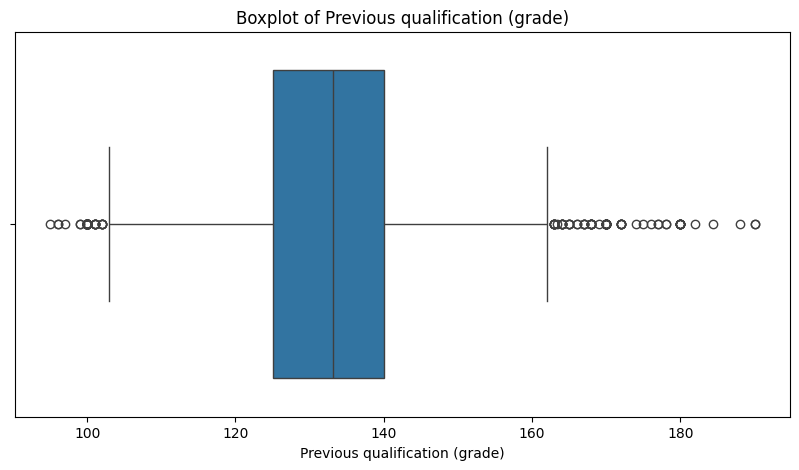

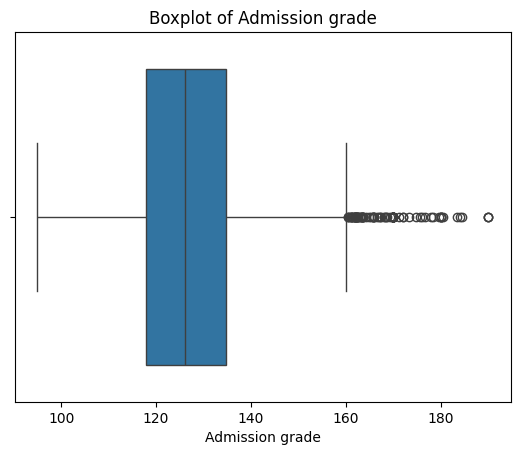

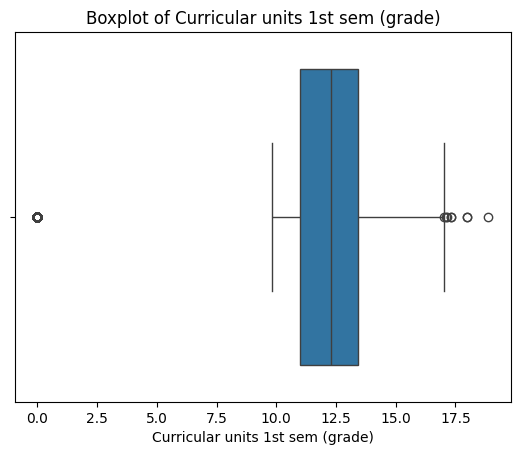

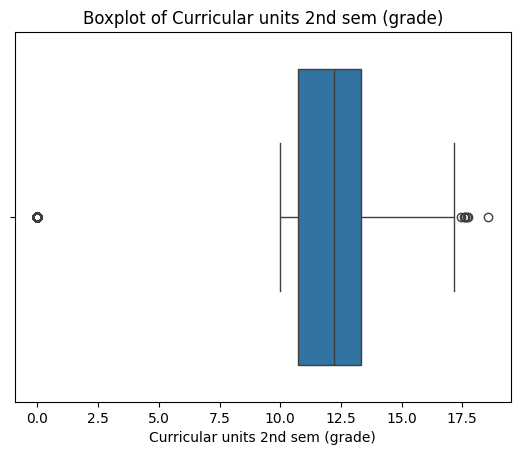

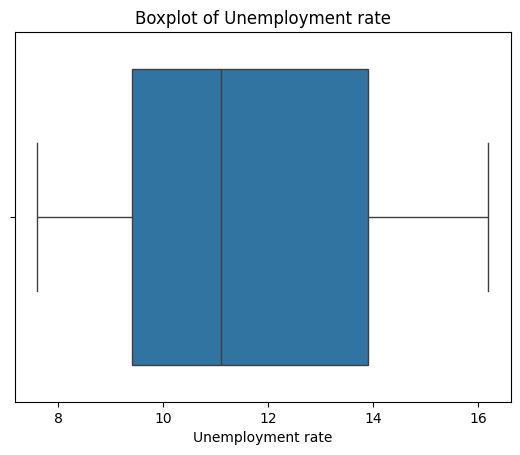

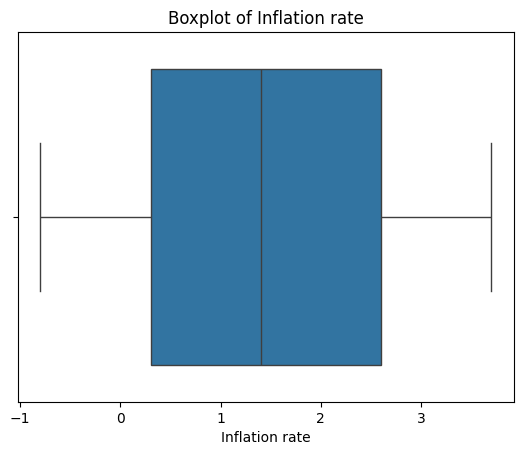

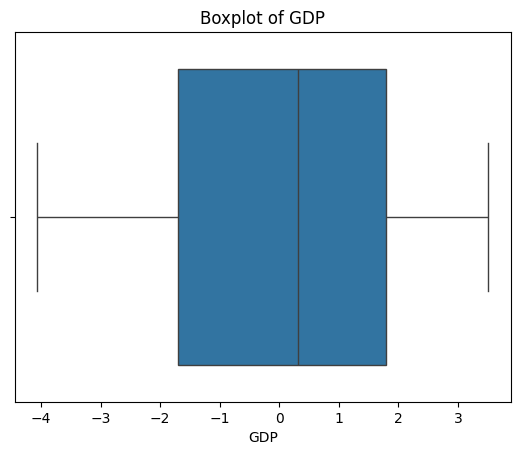

In [ ]:
# Define a class to visualize the distribution of continuous variables using boxplots

class BoxplotVisualizer: # Initialize the class with the dataset
    def __init__(self, data):
        self.data = data # Store the dataset to be analyzed
        self.data_num = self.data.select_dtypes(include=['float64']) # Select only the numerical (continuous) columns (i.e., columns with dtype 'float64')

    # Method to plot a boxplot for each continuous variable
    def plot_boxplots(self):
        plt.figure(figsize=(10, 5)) # Set the size of the figure to make the plots larger and easier to read

        # Loop through each column in the numerical data to plot its boxplot
        for column in self.data_num.columns:
            # Plot a boxplot for the current column, showing the distribution and identifying outliers
            sns.boxplot(x=self.data[column])  # 'x' is used here to indicate that each boxplot corresponds to a variable
            plt.title(f"Boxplot of {column}") # Set the title of the plot for the current column
            plt.show()

boxplot_visualizer = BoxplotVisualizer(data) # Create an instance of BoxplotVisualizer with the dataset
boxplot_visualizer.plot_boxplots() # Call the method to plot the boxplots of each continuous variable


From the above charts we can observe that the almost each feature contains an outliers except Unemployment rate, Inflation rate, and GDP.

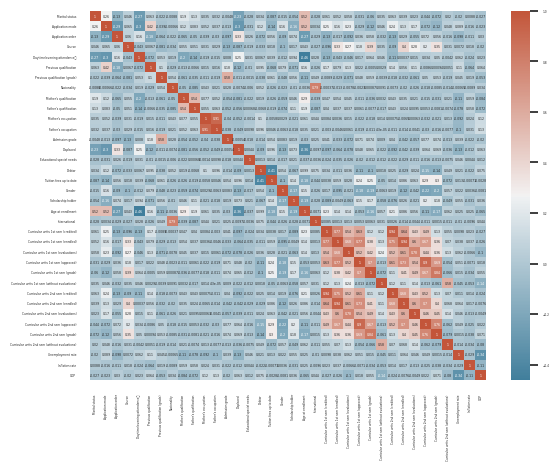

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class CorrelationHeatmapGenerator: # Initialize the class with the dataset and optional parameters for the plot
    def __init__(self, data: pd.DataFrame, target_column: str, font_scale: float = 0.19, cmap_palette: tuple = (230, 20)):
        self.data = data
        self.target_column = target_column  # The name of the target column to exclude
        self.font_scale = font_scale  # Font scale for annotations
        self.cmap_palette = cmap_palette  # Color map for the heatmap
        sns.set(font_scale=self.font_scale)  # Set the font scale for Seaborn plots

    # Method to calculate the correlation matrix after dropping the target column
    def calculate_correlation(self):
        return self.data.drop(self.target_column, axis=1, inplace=False).corr() # Drop the target column and calculate the correlation of the remaining columns

    # Method to generate the heatmap plot
    def generate_heatmap(self):
        correlation_numeric = self.calculate_correlation() # Calculate the correlation matrix
        cmap = sns.diverging_palette(self.cmap_palette[0], self.cmap_palette[1], as_cmap=True) # Create a custom diverging color map using the specified palette
        sns.heatmap(correlation_numeric, annot=True, cmap=cmap) # Generate the heatmap with annotations and the custom color map

    # Method to save the heatmap as a PNG file
    def save_heatmap(self, filename: str = 'correlation_heatmap.png', dpi: int = 500):
        self.generate_heatmap()  # Generate the heatmap before saving
        plt.savefig(filename, dpi=dpi)  # Save the heatmap to a file with high resolution

# Assuming 'data' is your DataFrame and 'Target' is the column to exclude from the correlation matrix
heatmap_generator = CorrelationHeatmapGenerator(data, target_column='Target')  # Create an instance of the class
heatmap_generator.save_heatmap()  # Generate and save the heatmap to a file

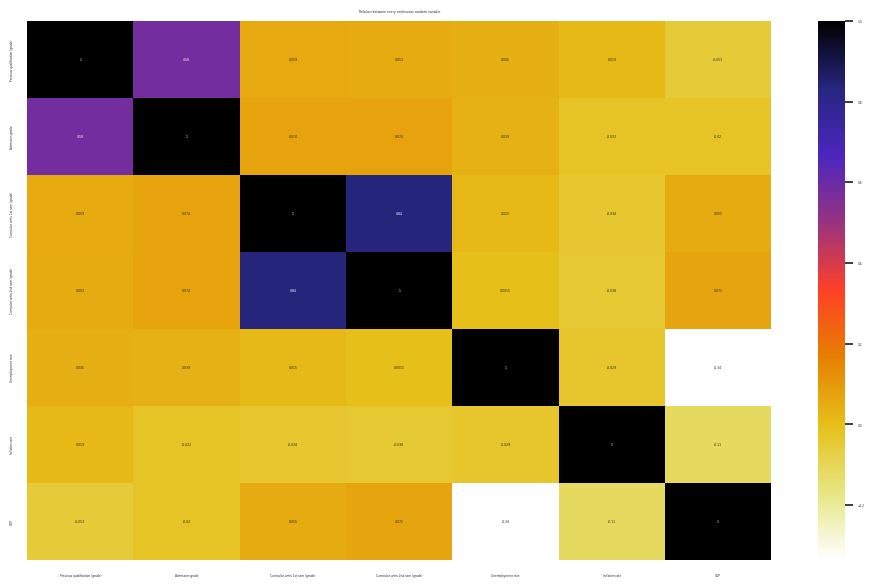

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a class to generate a correlation heatmap
class CorrelationHeatmap: # Initialize the class with the data and optional parameters for the plot
    def __init__(self, data: pd.DataFrame, figsize: tuple = (12, 7), cmap: str = 'CMRmap_r', title: str = 'Relation between every continuous random variable'):
        self.data = data  # The numerical data
        self.figsize = figsize
        self.cmap = cmap  # Color map for the heatmap
        self.title = title

    # Method to calculate the correlation matrix
    def calculate_correlation(self):
        return self.data.corr()  # Compute pairwise correlation of columns

    # Method to generate and display the heatmap
    def generate_heatmap(self):
        cor = self.calculate_correlation()  # Calculate the correlation matrix
        plt.figure(figsize=self.figsize)  # Set the figure size
        sns.heatmap(cor, annot=True, cmap=self.cmap)  # Generate the heatmap with annotations and the specified color map
        plt.title(self.title)  # Set the title of the plot
        plt.show()

# Assuming data_num is your DataFrame with numerical data
heatmap = CorrelationHeatmap(data_num)  # Create an instance of the CorrelationHeatmap class
heatmap.generate_heatmap()  # Generate and show the heatmap

From the above plot we can observe that Curricular_units_1st_sem_(grade) & Curricular_units_2nd_sem_(grade) having strong correlation between them and Previous_qualification_(grade) & Admission_grade is having average relation between them, whereas GDP, inflation rate, and unemployment rate having negative relation between them.

####**visualizing the discrete (categorical) random variables**

In [ ]:
class DataColumnSelector:
    def __init__(self, data):
        self.data = data
        self.num_data = self._get_numerical_columns()
        self.cat_cols = self._get_categorical_columns()
        self.cols = self._get_difference_columns()

    def _get_numerical_columns(self):
        return [cname for cname in self.data.columns if self.data[cname].dtypes in ['float64']]

    def _get_categorical_columns(self):
        return self.data._get_numeric_data().columns

    def _get_difference_columns(self):
        return list(set(self.cat_cols) - set(self.num_data))

    def get_data_info(self):
        return {
            "Numerical Columns": self.num_data,
            "Categorical Columns": self.cat_cols,
            "Difference Columns": self.cols,
            "Number of Difference Columns": len(self.cols),
            "Data Sample": self.data.head()
        }

selector = DataColumnSelector(data)
data_info = selector.get_data_info()

print(data_info["Numerical Columns"])
print(data_info["Categorical Columns"])
print(data_info["Difference Columns"])
print(data_info["Number of Difference Columns"])
print(data_info["Data Sample"])

['Previous qualification (grade)', 'Admission grade', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Unemployment rate', 'Inflation rate', 'GDP']
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)

## **visualizing the Categorical Data**

### Univeriate and Bi-variate Analysis

Cleaned Column Names: Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime/evening_attendance\t', 'Previous_qualification',
       'Previous_qualification_(grade)', 'Nacionality',
       'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation',
       'Fathers_occupation', 'Admission_grade', 'Displaced',
       'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date',
       'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_(credited)',
       'Curricular_units_1st_sem_(enrolled)',
       'Curricular_units_1st_sem_(evaluations)',
       'Curricular_units_1st_sem_(approved)',
       'Curricular_units_1st_sem_(grade)',
       'Curricular_units_1st_sem_(without_evaluations)',
       'Curricular_units_2nd_sem_(credited)',
       'Curricular_units_2nd_sem_(enrolled)',
       'Curricular_units_2nd_sem_(evaluations)',
       'Curricular_units_2nd_sem_(approved)',
       'Curricula

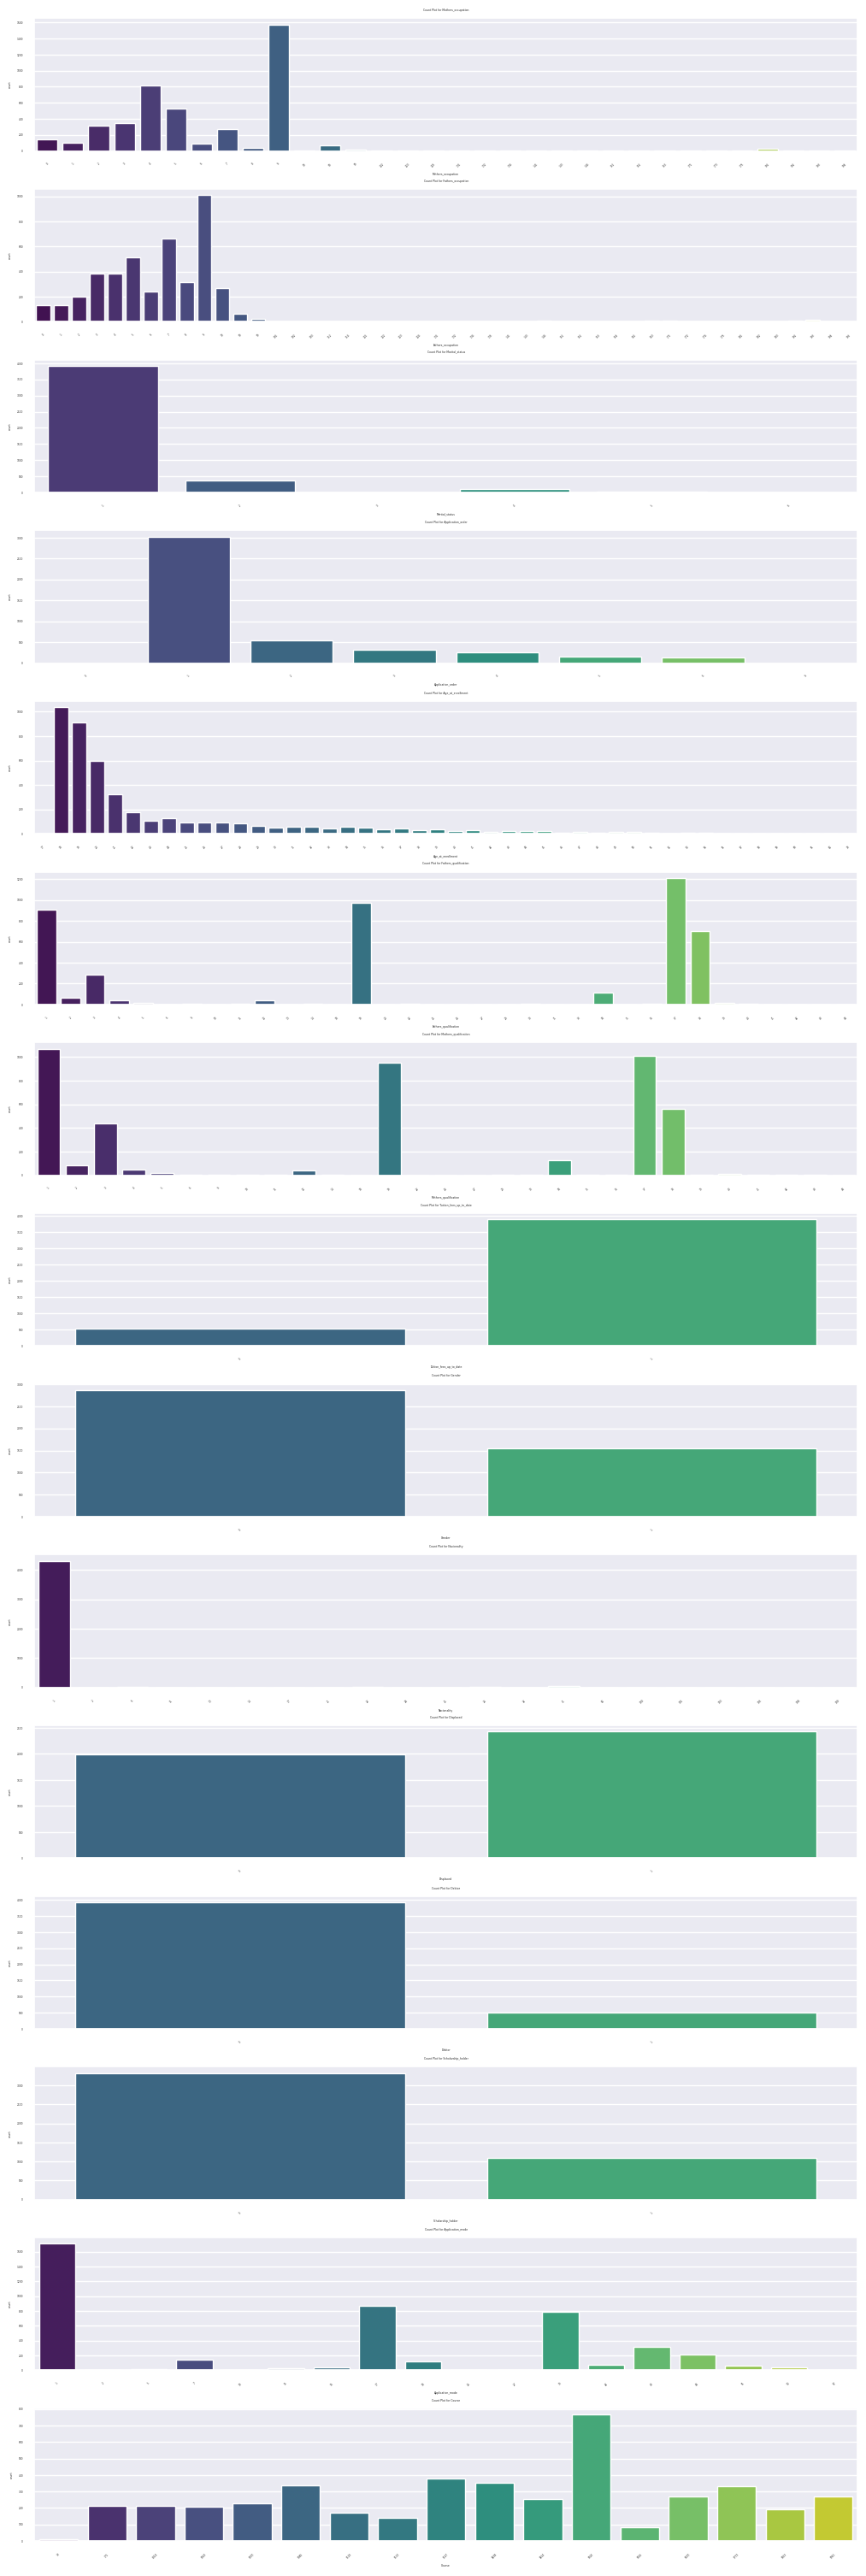

In [ ]:
# Import necessary libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Define a class for creating count plots to visualize the distribution of categorical variables
class CountPlotVisualizer:
    def __init__(self, data, columns, rows=15, cols=1, figsize=(10, 30), palette='Set2'): # Initialize the class with the dataset, columns to plot, and layout parameters for the subplots
        self.data = data # Store the dataset to be visualized
        self.columns = columns # List of columns to plot
        self.rows = rows # Number of rows in the subplot grid
        self.cols = cols # Number of columns in the subplot grid
        self.figsize = figsize
        self.palette = palette # Color palette for the plots

        # Create a grid of subplots based on the specified number of rows and columns
        self.fig, self.ax = plt.subplots(nrows=self.rows, ncols=self.cols, figsize=self.figsize)

        # Flatten the axes array to make indexing easier, especially when there are multiple subplots
        self.ax = self.ax.flatten()

    def plot_countplots(self): # Method to generate the count plots for the specified columns
        for ind, col in enumerate(self.columns): # Loop through each specified column and create a count plot for each
            sns.countplot(x=col, data=self.data, ax=self.ax[ind], palette=self.palette) # Create a count plot for the current column using seaborn's countplot
            self.ax[ind].set_title(f"Count Plot for {col}") # Set the title for each subplot to indicate the variable being visualized
            self.ax[ind].tick_params(axis='x', rotation=45)  # Rotate the x-axis labels by 45 degrees for better readability if necessary

        plt.tight_layout() # Adjust the layout to avoid overlapping plots and titles
        plt.show()

# Define a list of categorical columns to visualize (ensure these columns are in your dataset)
cols_ = ['Mothers_occupation', 'Fathers_occupation', 'Marital_status', 'Application_order', 'Age_at_enrollment',
         'Fathers_qualification', 'Mothers_qualification', 'Tuition_fees_up_to_date', 'Gender', 'Nacionality',
         'Displaced', 'Debtor', 'Scholarship_holder', 'Application_mode', 'Course']

# Clean column names by replacing spaces with underscores and removing special characters
data.columns = data.columns.str.replace(' ', '_').str.replace("'", "")
print("Cleaned Column Names:", data.columns)

# Verify if the required columns exist in the dataset
missing_cols = [col for col in cols_ if col not in data.columns]
print("Missing Columns:", missing_cols)

visualizer = CountPlotVisualizer(data, columns=cols_, palette='viridis') # Create an instance of CountPlotVisualizer with the specified columns and color palette
visualizer.plot_countplots() # Call the method to plot the count plots for the selected categorical variables

 Insights

1. Maximum mothers are actually unskilled workers, followed by administrative staff, safety workers and sellers.
2. Maximum student's fathers are unskilled workers, followed by skilled workers in industry, safety workers, security staffs and sellers.
3. More than 90% of students from the given dataset are single.
4. Maximum students are enrolled at the age of 18, 19, and 20.
5. Maximum parents are having a very basic level of education starting from class 5th to 12th.
6. More than 90% students submit their tution fees on time.
7. In this group of students, more than 60% are females.
8. Almost every student in this group belongs to Portuguese.
9. Maximum students in this group are not the scholarship holders,
10. Maximum students in the group are followed the 1st phase of application mode followed by 2nd phase.
11. Maximum students enrolled themselves for the Nursing course followed by management, social service, journalism and communication course.

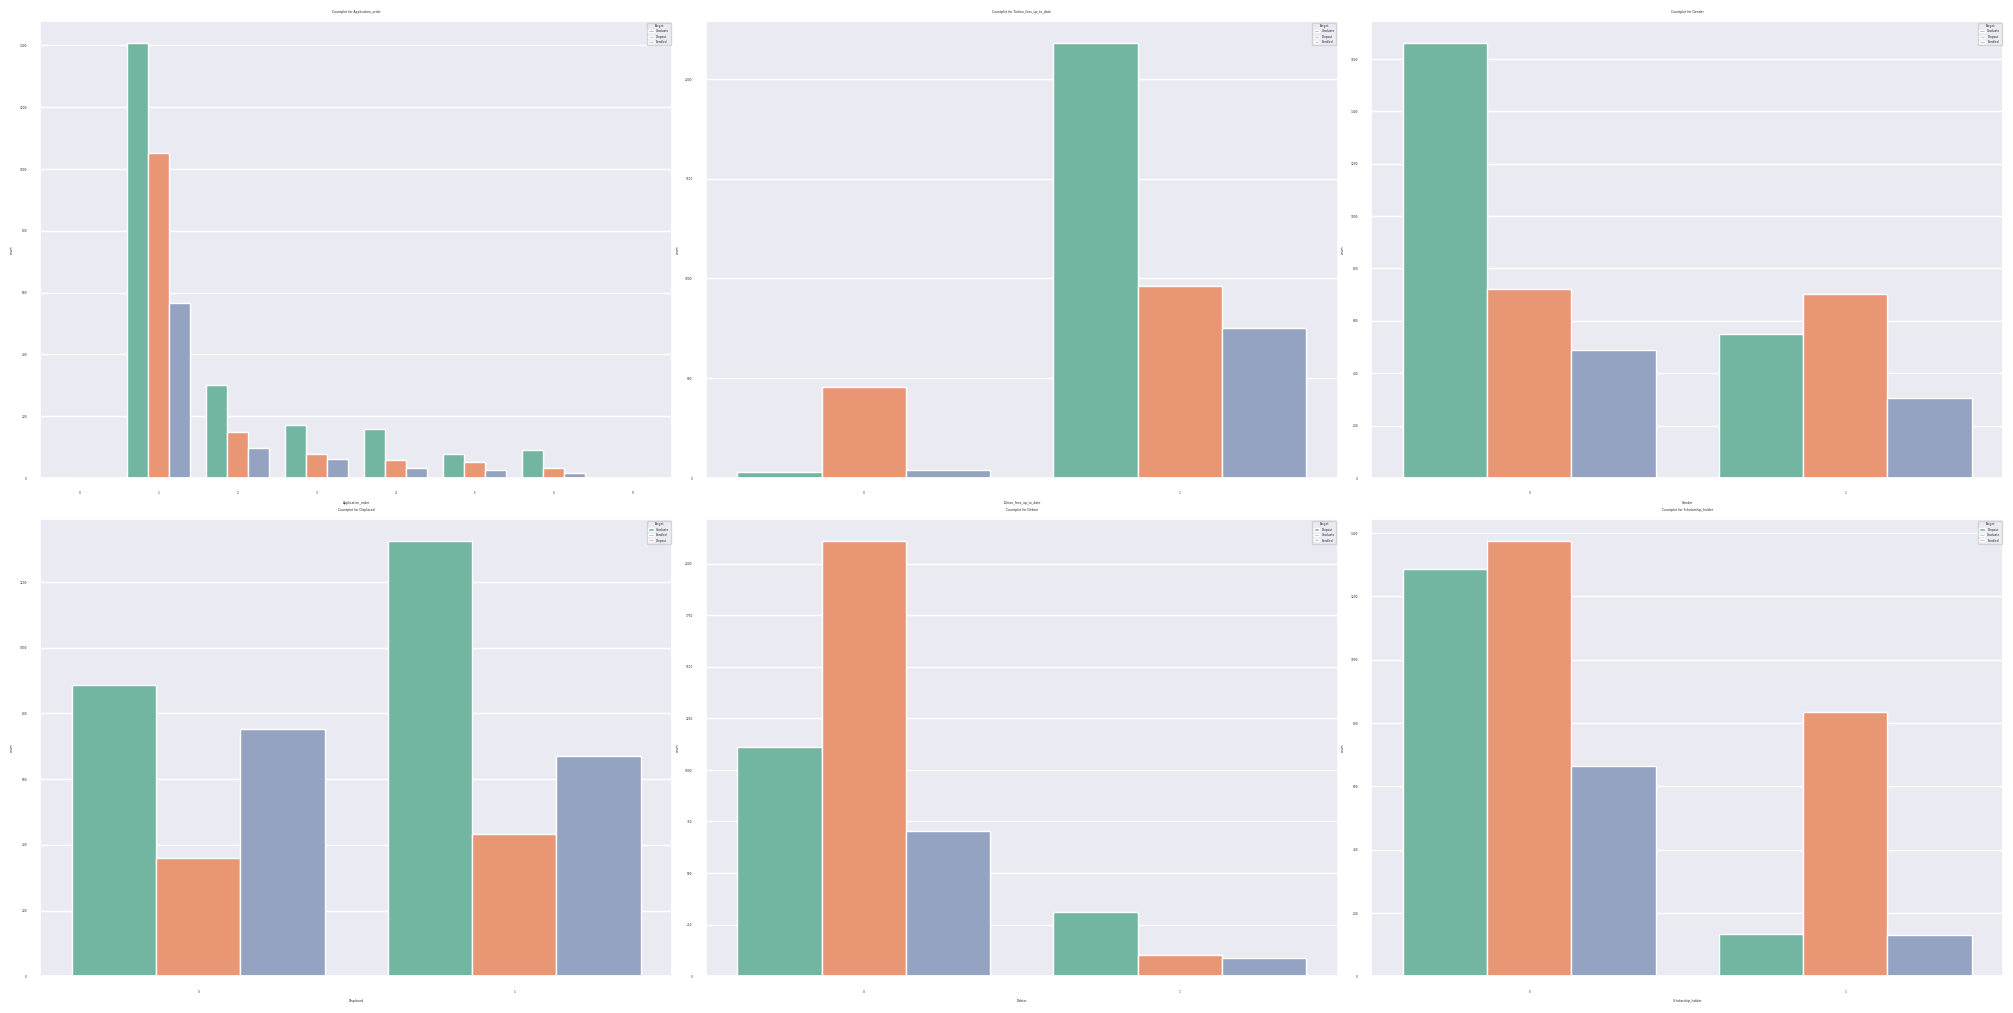

In [ ]:
# Define a class to visualize the effect of each variable on the target variable using count plots

class CountPlotGridVisualizer: # Initialize the class with the dataset, columns to plot, and parameters for the grid layout
    def __init__(self, data, columns, hue, rows=2, cols=3, figsize=(20, 10), palette='Set2'):
        self.data = data # Initialize the class with the dataset, columns to plot, and parameters for the grid layout
        self.columns = columns # List of columns to plot
        self.hue = hue # The target variable  to be used for color coding the count plots
        self.rows = rows # Number of rows in the grid for count plots
        self.cols = cols # Number of columns in the grid for count plots
        self.figsize = figsize
        self.palette = palette

    # Method to generate a grid of count plots
    def plot_countplot_grid(self):
        # Check if all columns exist in the data
        missing_columns = [col for col in self.columns if col not in self.data.columns]
        if missing_columns:
            raise ValueError(f"Columns missing in the data: {', '.join(missing_columns)}") # Raise an error if any columns are missing

        # Check if the hue column exists in the dataset
        if self.hue not in self.data.columns:
            raise ValueError(f"The 'hue' column '{self.hue}' is missing in the data.") # Raise an error if the hue column is missing

        fig, ax = plt.subplots(self.rows, self.cols, figsize=self.figsize) # Create the grid of subplots based on the specified number of rows and columns
        ax = ax.flatten() if self.rows > 1 else [ax] # Flatten the axes if there are multiple row

        # Loop through each column to plot a countplot for each
        for i, col in enumerate(self.columns):
            sns.countplot(x=col, hue=self.hue, data=self.data, palette=self.palette, ax=ax[i]) # Create a count plot for the current column with the target variable as the hue
            ax[i].set_title(f"Countplot for {col}")  # Set the title for each subplot

        plt.tight_layout() # Adjust the layout to avoid overlap of plots
        plt.show()

# List of categorical columns to visualize, showing their effect on the target variable
columns_to_plot = [
    'Application_order', 'Tuition_fees_up_to_date', 'Gender',
    'Displaced', 'Debtor', 'Scholarship_holder'
]

plotter = CountPlotGridVisualizer(data, columns=columns_to_plot, hue='Target')
plotter.plot_countplot_grid() # Call the method to plot the grid of count plots for the selected columns

Insights

1. We can observe here that those students who has not submitted the tution fees on time, they are having a higher chance of dropout.
2. Maximum males are droping out.
3. The students who are in debt, they are having a higher chance of droping out.

## **Feature Engineering/ Feature Selection**

### Handling Categorical Data

In [ ]:
# Define a class to encode categorical variables into numerical values

class CategoricalEncoder: # Initialize the class with the dataset and a LabelEncoder instance
    def __init__(self, data):
        self.data = data # Store the dataset to be transformed
        self.le = LabelEncoder() # Initialize LabelEncoder for encoding categorical variables

    # Method to encode the target column from categorical to numerical values
    def encode_target(self, column_name):
        self.data[column_name] = self.le.fit_transform(self.data[column_name]) # Apply label encoding to the specified column and update it in the dataset
        return self.data

encoder = CategoricalEncoder(data) # Create an instance of CategoricalEncoder with the dataset
data = encoder.encode_target('Target') # Encode the 'Target' column from categorical to numerical values

print(data.head())


   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening_attendance\t  Previous_qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous_qualification_(grade)  Nacionality  Mothers_qualification  \
0                           122.0            1                     19   
1                           160.0            1                      1   
2                           1

### Outlier Handling

In [ ]:
# This is useful for checking which columns are included in the DataFrame after filtering the numerical variables (float64 type).

data_num.columns

Index(['Previous qualification (grade)', 'Admission grade',
       'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
       'Unemployment rate', 'Inflation rate', 'GDP'],
      dtype='object')

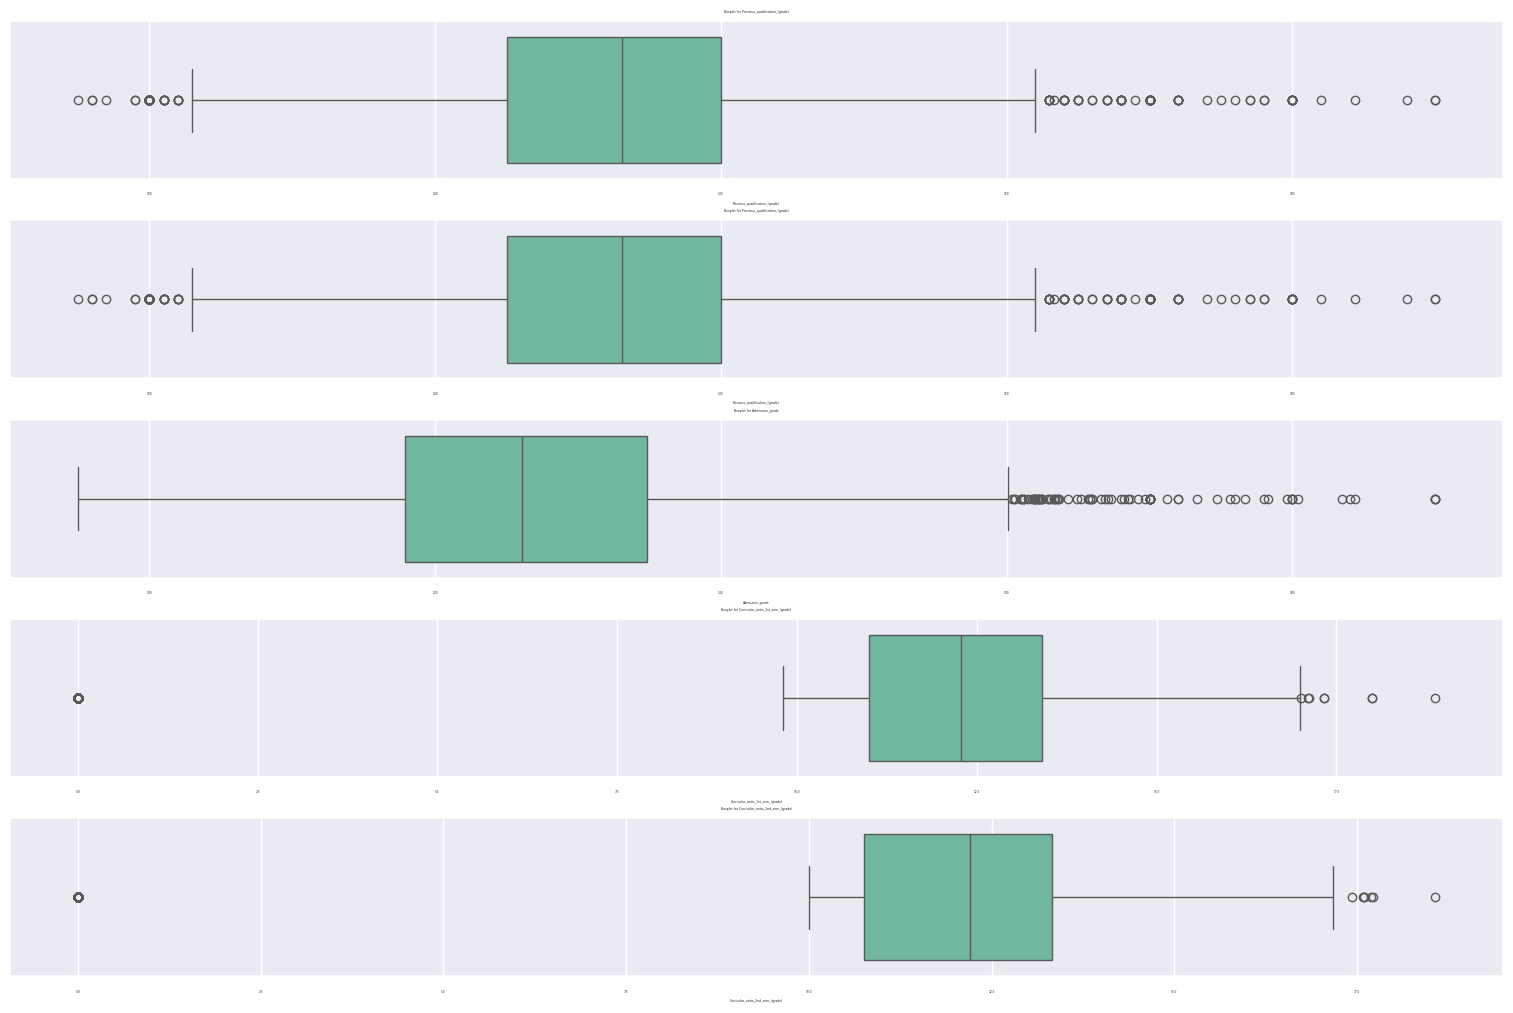

In [ ]:
# Define a class to visualize the boxplot of numerical columns before handling outliers

class BoxplotVisualizer: # Initialize the class with the dataset, columns to plot, and subplot layout parameters
    def __init__(self, data, columns, rows=5, cols=1, figsize=(15, 10), palette='BuGn'):
        self.data = data # The dataset containing the columns to visualize
        self.columns = columns # List of columns to generate boxplots for
        self.rows = rows # Number of rows in the subplot grid
        self.cols = cols # Number of columns in the subplot grid
        self.figsize = figsize
        self.palette = palette

    # Method to generate boxplots for the specified columns
    def plot_boxplots(self):
        fig, axs = plt.subplots(self.rows, self.cols, figsize=self.figsize)  # Create subplots with the specified number of rows and columns
        axs = axs.flatten() if self.rows > 1 else [axs] # Flatten the axes array if there are multiple rows, otherwise, make it a list with one element

        # Loop through each column in the columns list to generate boxplots
        for i, col in enumerate(self.columns):
            if col in self.data.columns: # Check if the column exists in the data
                sns.boxplot(x=self.data[col], ax=axs[i], palette=self.palette) # Create a boxplot for the current column using seaborn's boxplot function
                axs[i].set_title(f"Boxplot for {col}") # Set the title for each boxplot
            else:
                # If the column is not found in the data, display a message
                axs[i].set_title(f"Column '{col}' not found in data")
                axs[i].text(0.5, 0.5, f"Column '{col}' not found", ha='center', va='center', fontsize=12)

        plt.tight_layout() # Adjust layout to avoid overlapping of plots and titles
        plt.show()

# List of columns to generate boxplots for
columns_to_plot = [
    'Previous_qualification_(grade)', 'Previous_qualification_(grade)', 'Admission_grade',
    'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)'
]

plotter = BoxplotVisualizer(data, columns=columns_to_plot) # Create an instance of BoxplotVisualizer with the dataset and specified columns
plotter.plot_boxplots() # Call the method to plot the boxplots for the specified columns

In [ ]:
data[['Previous_qualification_(grade)', 'Admission_grade','Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)']].describe()

,Previous_qualification_(grade),Admission_grade,Curricular_units_1st_sem_(grade),Curricular_units_2nd_sem_(grade)
count,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,10.640822,10.230206
std,13.188332,14.482001,4.843663,5.210808
min,95.000000,95.000000,0.000000,0.000000
25%,125.000000,117.900000,11.000000,10.750000
50%,133.100000,126.100000,12.285714,12.200000
75%,140.000000,134.800000,13.400000,13.333333
max,190.000000,190.000000,18.875000,18.571429


In [ ]:
# Outlier Treatment for the 'Previous_qualification_(grade)' column

# Step 1: Calculate the first quartile (Q1) and third quartile (Q3) for 'Previous_qualification_(grade)'
# Q1 is the 25th percentile, and Q3 is the 75th percentile of the data

Q1 = data['Previous_qualification_(grade)'].quantile(0.25)
Q3 = data['Previous_qualification_(grade)'].quantile(0.75)

# Step 2: Calculate the Interquartile Range (IQR), which is the difference between Q3 and Q1
# IQR helps in detecting outliers, with values outside the range of 1.5*IQR or more considered outliers
IQR = Q3 - Q1

# Step 3: Filter out the outliers using the IQR method
# Outliers are defined as values outside the range of (Q1 - 3*IQR) to (Q3 + 3*IQR)
# The data is filtered to only include values within this range, removing extreme outliers
data = data[(data['Previous_qualification_(grade)'] >= Q1 - 3*IQR) & (data['Previous_qualification_(grade)'] <= Q3 + 3*IQR)]

In [ ]:
# Outlier Treatment for the 'Admission_grade' column

# Step 1: Calculate the first quartile (Q1) and third quartile (Q3) for 'Admission_grade'
# Q1 is the 25th percentile, and Q3 is the 75th percentile of the data
Q1 = data['Admission_grade'].quantile(0.25)
Q3 = data['Admission_grade'].quantile(0.75)

# Step 2: Calculate the Interquartile Range (IQR), which is the difference between Q3 and Q1
# IQR helps in detecting outliers, with values outside the range of 1.5*IQR or more considered outliers
IQR = Q3 - Q1

# Step 3: Filter out the outliers using the IQR method
# Outliers are defined as values outside the range of (Q1 - 3*IQR) to (Q3 + 3*IQR)
# The data is filtered to only include values within this range, removing extreme outliers
data = data[(data['Admission_grade'] >= Q1 - 3*IQR) & (data['Admission_grade'] <= Q3 + 3*IQR)]

In [ ]:
# Outlier Treatment for the 'Curricular_units_1st_sem_(grade)' column

# Step 1: Calculate the first quartile (Q1) and the third quartile (Q3) of the 'Curricular_units_1st_sem_(grade)' column
# Q1 is the 25th percentile, and Q3 is the 75th percentile of the data
Q1 = data['Curricular_units_1st_sem_(grade)'].quantile(0.25)
Q3 = data['Curricular_units_1st_sem_(grade)'].quantile(0.75)

# Step 2: Calculate the Interquartile Range (IQR), which is the difference between Q3 and Q1
# IQR helps in detecting outliers, as values outside 1.5*IQR are considered outliers
IQR = Q3 - Q1

# Step 3: Filter out the outliers using the IQR method
# Outliers are defined as values outside the range of (Q1 - 3*IQR) to (Q3 + 3*IQR)
# The data is filtered to only include values within this range, effectively removing outliers
data = data[(data['Curricular_units_1st_sem_(grade)'] >= Q1 - 3*IQR) & (data['Curricular_units_1st_sem_(grade)'] <= Q3 + 3*IQR)]

In [ ]:
# Outlier Treatment for the 'Curricular_units_2nd_sem_(grade)' column

# Step 1: Calculate the first quartile (Q1) and third quartile (Q3) for 'Curricular_units_2nd_sem_(grade)'
# Q1 is the 25th percentile, and Q3 is the 75th percentile of the data
Q1 = data['Curricular_units_2nd_sem_(grade)'].quantile(0.25)
Q3 = data['Curricular_units_2nd_sem_(grade)'].quantile(0.75)

# Step 2: Calculate the Interquartile Range (IQR), which is the difference between Q3 and Q1
# IQR helps in detecting outliers, with values outside the range of 1.5*IQR or more considered outliers
IQR = Q3 - Q1

# Step 3: Filter out the outliers using the IQR method
# Outliers are defined as values outside the range of (Q1 - 3*IQR) to (Q3 + 3*IQR)
# The data is filtered to only include values within this range, removing extreme outliers
data = data[(data['Curricular_units_2nd_sem_(grade)'] >= Q1 - 3*IQR) & (data['Curricular_units_2nd_sem_(grade)'] <= Q3 + 3*IQR)]

In [ ]:
data[['Previous_qualification_(grade)', 'Admission_grade', 'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)']].describe()

,Previous_qualification_(grade),Admission_grade,Curricular_units_1st_sem_(grade),Curricular_units_2nd_sem_(grade)
count,3509.000000,3509.000000,3509.000000,3509.000000
mean,132.599231,127.084981,12.749182,12.745582
std,12.977814,13.769560,1.328290,1.372024
min,95.000000,95.000000,10.000000,10.000000
25%,124.000000,118.400000,11.800000,11.750000
50%,133.000000,126.300000,12.666667,12.666667
75%,140.000000,134.500000,13.600000,13.666667
max,184.400000,184.400000,18.875000,18.571429


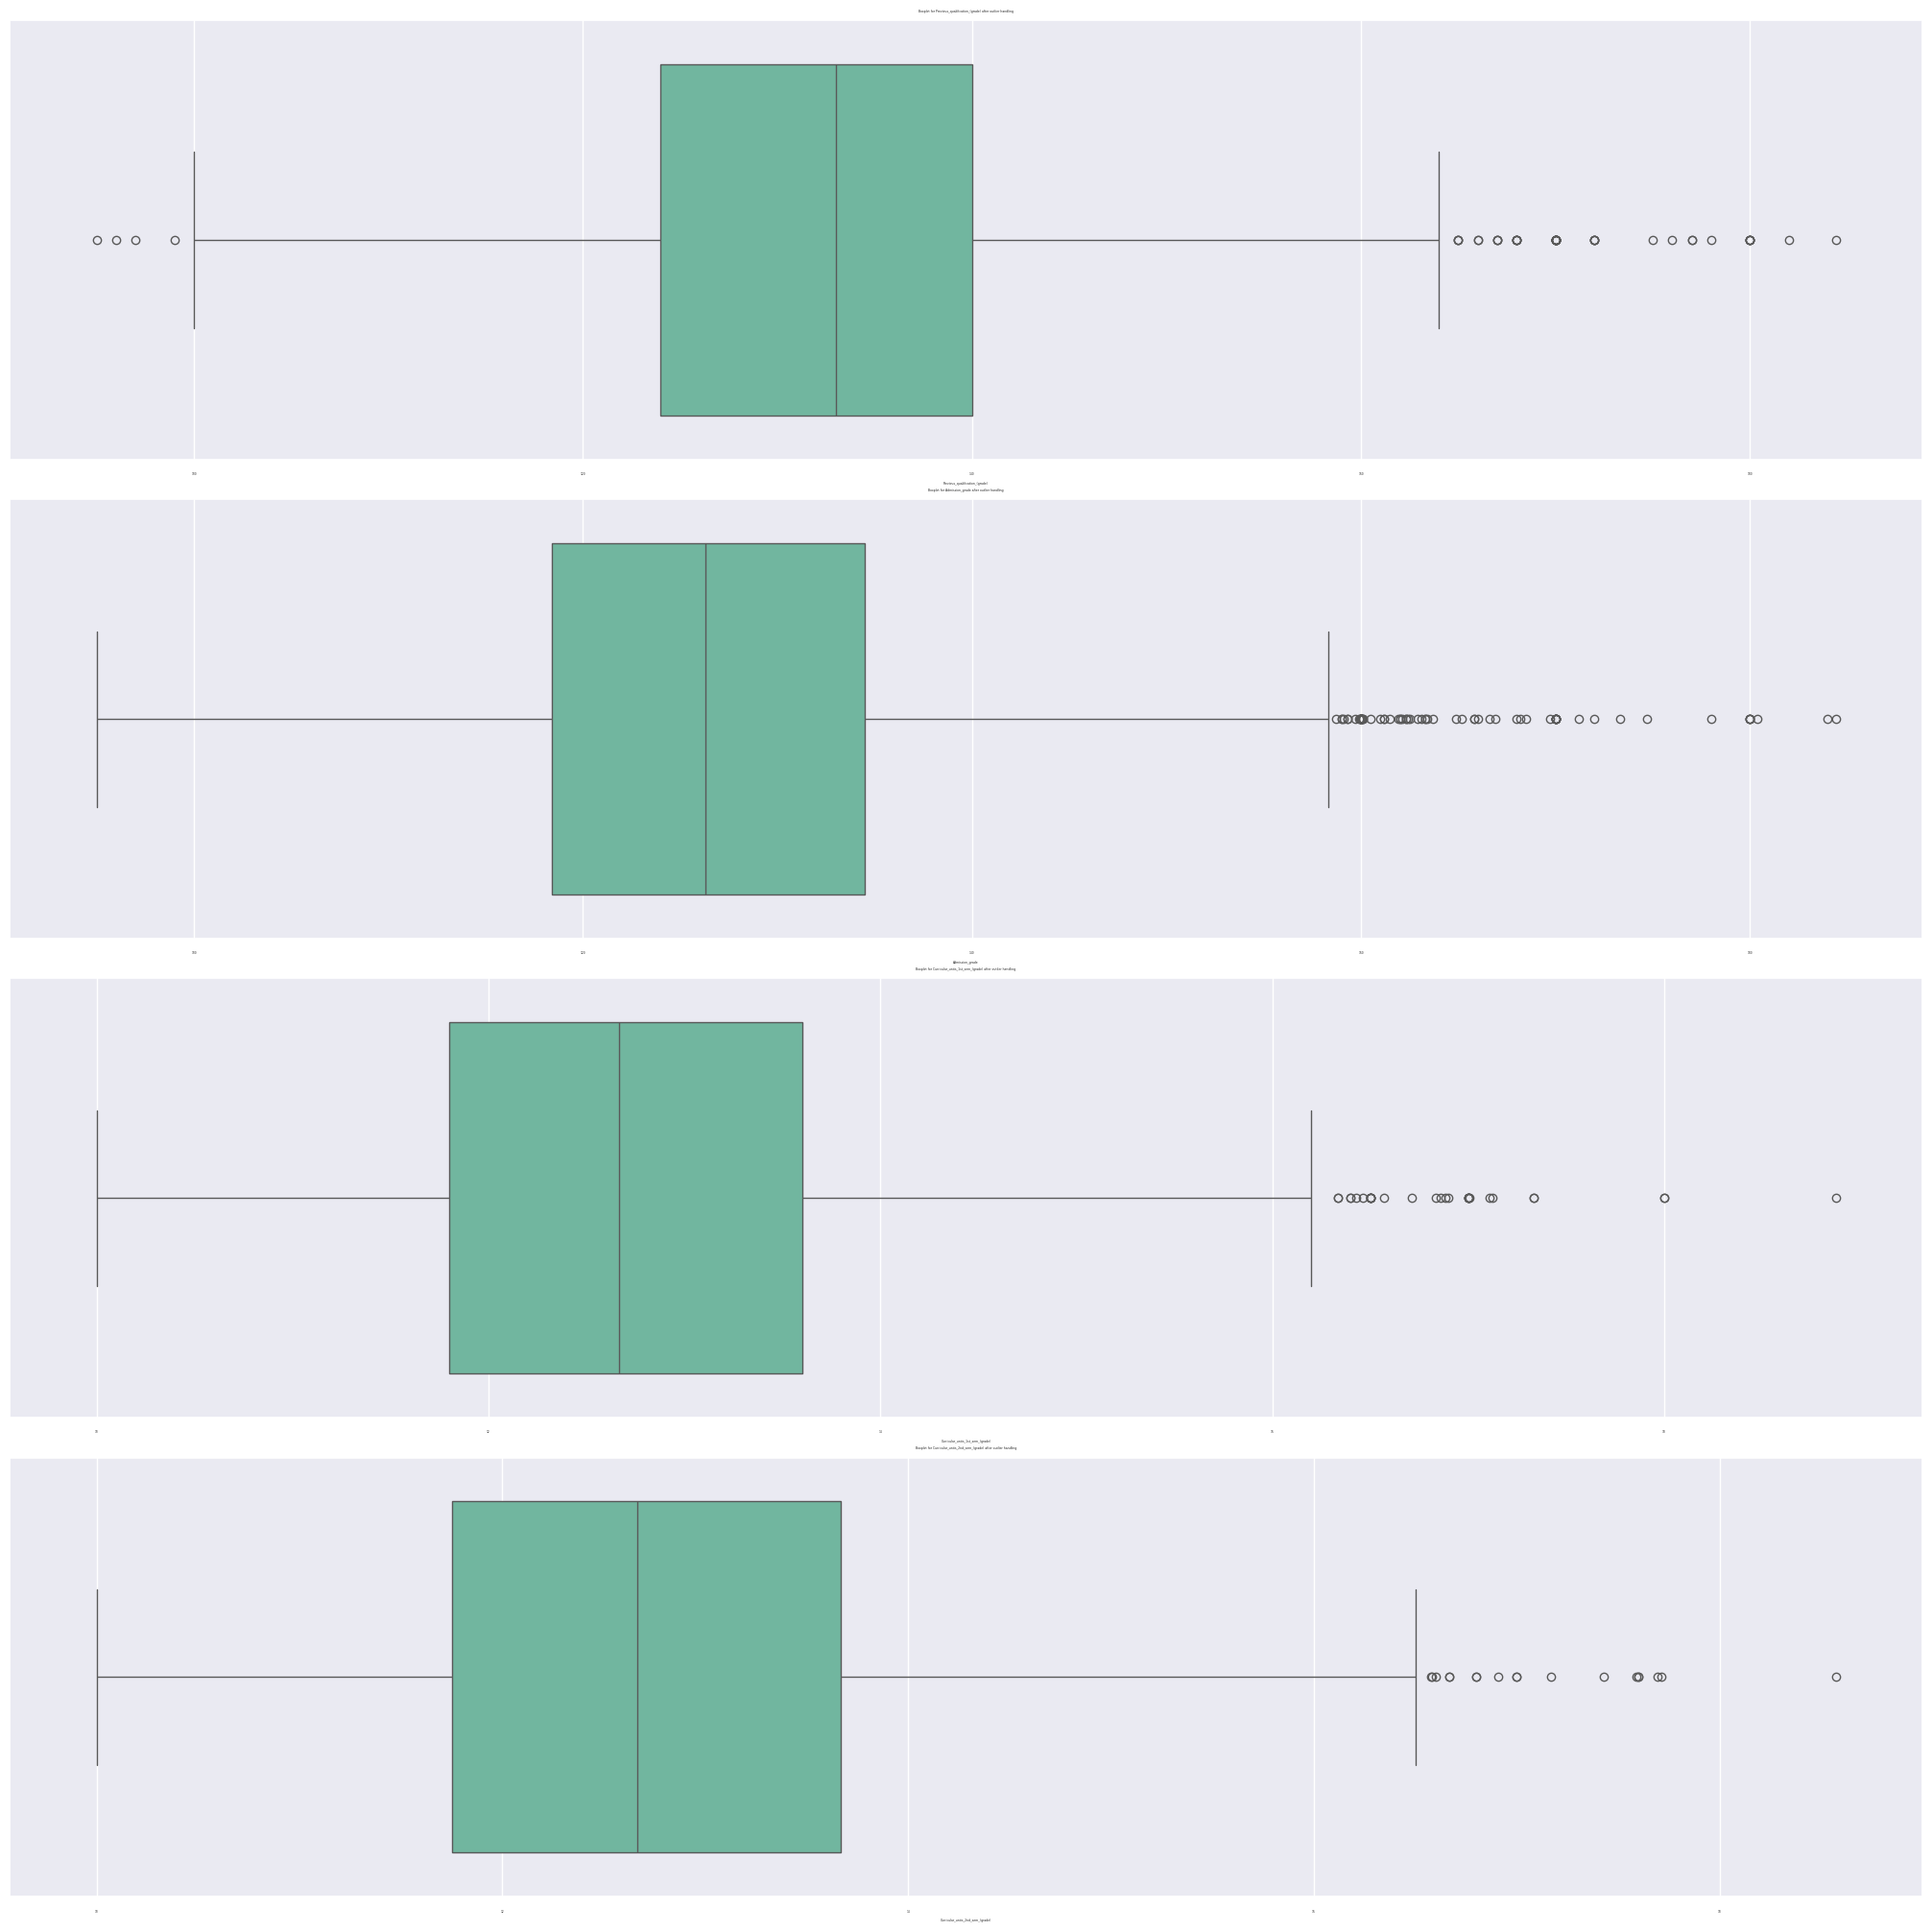

In [ ]:
# Define a class to visualize the boxplot for the specified columns after outlier handling

class BoxplotVisualizer:
    # Initialize the class with the dataset, columns to plot, and subplot layout parameters
    def __init__(self, data, columns, rows=4, cols=1, figsize=(20, 20), palette='BuGn'):
        self.data = data # The dataset containing the columns to visualize
        self.columns = columns # List of columns to generate boxplots for
        self.rows = rows # Number of rows in the subplot grid
        self.cols = cols # Number of columns in the subplot grid
        self.figsize = figsize # Size of the entire figure (width, height)
        self.palette = palette # Color palette used for the boxplots

    # Method to generate boxplots for the specified columns
    def plot_boxplots(self):
        fig, axs = plt.subplots(self.rows, self.cols, figsize=self.figsize) # Create subplots with the specified number of rows and columns
        axs = axs.flatten() if self.rows > 1 else [axs] # Flatten the axes array if there are multiple rows, otherwise, make it a list with one element

        # Loop through each column in the columns list to generate boxplots
        for i, col in enumerate(self.columns):
            if col in self.data.columns: # Check if the column exists in the data
                sns.boxplot(x=self.data[col], ax=axs[i], palette=self.palette) # Create a boxplot for the current column using seaborn's boxplot function
                axs[i].set_title(f"Boxplot for {col} after outlier handling") # Set the title for each boxplot
            else:
                # If the column is not found in the data, display a message
                axs[i].set_title(f"Column '{col}' not found in data")
                axs[i].text(0.5, 0.5, f"Column '{col}' not found", ha='center', va='center', fontsize=12)

        plt.tight_layout() # Adjust layout to avoid overlap of plots and titles
        plt.show() # Display the boxplots

# List of columns to generate boxplots for after outlier handling
columns_to_plot = [
    'Previous_qualification_(grade)', 'Admission_grade',
    'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)'
]

plotter = BoxplotVisualizer(data, columns=columns_to_plot) # Create an instance of BoxplotVisualizer with the dataset and specified columns
# Call the method to plot the boxplots for the specified columns
plotter.plot_boxplots()

### Feature Selection using Chi-Square Test

Since we have 29 discrete (categorical) data, so we need to perform hypothesis testing to understand whether there is any relation between dependent and independent variables and then we can analyze the kind of relationship using graphs.
Let's have a chi-square test to understand the relation between target and independent variable.

In [ ]:
# Perform the Chi-squared test (chi2) to calculate the F-score and p-value for feature selection

from sklearn.feature_selection import chi2

In [ ]:
# Define 'X' as the input variables (features), which include various columns related to student details
X = data[['Curricular_units_2nd_sem_(enrolled)',
          'Scholarship_holder',
          'Application_order',
          'Curricular_units_1st_sem_(evaluations)',
          'Application_mode',
          'Course',
          'Nacionality',
          'Curricular_units_1st_sem_(without_evaluations)',
          'Curricular_units_2nd_sem_(without_evaluations)',
          'Age_at_enrollment',
          'Curricular_units_1st_sem_(credited)',
          'Curricular_units_2nd_sem_(credited)',
          'Debtor',
          'Daytime/evening_attendance\t',
          'Previous_qualification',
          "Mothers_qualification",
          "Mothers_occupation",
          'Curricular_units_1st_sem_(approved)',
          'Gender',                               # Gender of the student
          'Displaced',                            # Whether the student is displaced
          'Curricular_units_2nd_sem_(evaluations)',
          'Tuition_fees_up_to_date',
          "Fathers_qualification",
          'Curricular_units_2nd_sem_(approved)',
          'Curricular_units_1st_sem_(enrolled)',
          "Fathers_occupation"]]

y = data['Target'] # Define 'y' as the target variable, which is the 'Target' column indicating the dropout status or academic success

In [ ]:
# Compute the F-scores and p-values for each feature in X with respect to the target variable y
f_score = chi2(X, y)

In [ ]:
p_value = pd.Series(f_score[1],index = X.columns) # Convert the p-values into a pandas Series, using the feature names of X as the index
p_value = p_value.sort_values(ascending = True) # Sort the p-value series in ascending order

print(p_value)

Application_mode                                   0.000000e+00
Mothers_occupation                                 0.000000e+00
Fathers_occupation                                1.315731e-272
Curricular_units_2nd_sem_(approved)               1.597835e-148
Curricular_units_1st_sem_(approved)                6.108383e-92
Previous_qualification                             1.106835e-78
Age_at_enrollment                                  2.193555e-55
Curricular_units_2nd_sem_(evaluations)             5.509562e-53
Curricular_units_1st_sem_(evaluations)             3.685394e-47
Debtor                                             8.448138e-45
Course                                             9.805967e-41
Curricular_units_1st_sem_(credited)                1.879439e-40
Scholarship_holder                                 2.106448e-37
Mothers_qualification                              4.613949e-37
Curricular_units_2nd_sem_(credited)                4.435544e-33
Gender                                  

**According to Chi-Square (Test of Independence)**

1. Null Hypothesis -> Features are independent to each other.
2. Alternate Hypothesis -> Features are dependent.



*  If p-value ≥ 0.05, we failed to reject null hypothesis there is no relationship between target variable and input categorical features.

*  If p_value < 0.05, we can reject the null hypothesis that means target variables are dependent on input categorical variable.

In [ ]:
i_cols = [] # List to store features that do not have a statistically significant relationship with the target variable

significance_level = 0.05 # Set the significance level to 0.05, which is a common threshold for hypothesis testing

for i in p_value.index: # Loop through each feature and its associated p-value to determine whether to reject or accept the null hypothesis
    # If the p-value is less than or equal to the significance level, reject the null hypothesis
    if p_value[i] <= significance_level:
        print(i, '    :- Reject NULL HYPOTHESIS')
    else:
        print(i, '   :- ACCEPT NULL HYPOTHESIS')

        i_cols.append(i) # Add the feature to the list of features with no significant relationship

Application_mode     :- Reject NULL HYPOTHESIS
Mothers_occupation     :- Reject NULL HYPOTHESIS
Fathers_occupation     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(approved)     :- Reject NULL HYPOTHESIS
Curricular_units_1st_sem_(approved)     :- Reject NULL HYPOTHESIS
Previous_qualification     :- Reject NULL HYPOTHESIS
Age_at_enrollment     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(evaluations)     :- Reject NULL HYPOTHESIS
Curricular_units_1st_sem_(evaluations)     :- Reject NULL HYPOTHESIS
Debtor     :- Reject NULL HYPOTHESIS
Course     :- Reject NULL HYPOTHESIS
Curricular_units_1st_sem_(credited)     :- Reject NULL HYPOTHESIS
Scholarship_holder     :- Reject NULL HYPOTHESIS
Mothers_qualification     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(credited)     :- Reject NULL HYPOTHESIS
Gender     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(without_evaluations)     :- Reject NULL HYPOTHESIS
Fathers_qualification     :- Reject NULL HYPOTHESIS
Tuition_fee

In [ ]:
i_cols

['Daytime/evening_attendance\t']

From a chi square test, we can observe that there are only 4 features which are having no relation with the target variables, so we can simply drop those features and analyze rest of the features.

In [ ]:
# Drop columns that are not statistically significant (from 'i_cols') and won'

columns_to_drop = [col for col in i_cols if col in data.columns]
data.drop(labels=columns_to_drop, axis=1, inplace=True)

In [ ]:
data.head()

,Marital_status,Application_mode,Application_order,Course,Previous_qualification,Previous_qualification_(grade),Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,...,Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Target
1,1,15,1,9254,1,160.0,1,1,3,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
3,1,17,2,9773,1,122.0,1,38,37,5,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,1,100.0,1,37,38,9,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
5,2,39,1,9991,19,133.1,1,37,37,9,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,2
6,1,1,1,9500,1,142.0,1,19,38,7,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,2


### Data Pre-processing (Splitting & Balancing the dataset)

In [ ]:
# Display the first 5 rows of the dataset to get an overview of the data structure
data.head()

,Marital_status,Application_mode,Application_order,Course,Previous_qualification,Previous_qualification_(grade),Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,...,Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Target
1,1,15,1,9254,1,160.0,1,1,3,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
3,1,17,2,9773,1,122.0,1,38,37,5,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,1,100.0,1,37,38,9,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
5,2,39,1,9991,19,133.1,1,37,37,9,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,2
6,1,1,1,9500,1,142.0,1,19,38,7,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,2


In [ ]:
# Display the dimensions of the dataset (number of rows and columns)
data.shape

(3509, 36)

In [ ]:
X = data.drop('Target', axis = 1) # Drop the 'Target' column from the dataset
y = data.Target # Assign the 'Target' column as the target variable

In [ ]:
# SMOTE is used to balance imbalanced datasets by generating synthetic samples for the minority class
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 23) # Initialize SMOTE with a fixed random state for reproducibility
X_sm, y_sm = sm.fit_resample(X, y) # Resample the input features (X) and target (y) to balance the classes

In [ ]:
# Split the dataset into training and test sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test_classifiers = train_test_split(X, y, test_size = 0.2, random_state = 23) # The random_state is set for reproducibility of the split

## **Model Building & Evaluation**

In [ ]:
from sklearn.naive_bayes import GaussianNB # Import classifiers for model training and evaluation
from sklearn.tree import DecisionTreeClassifier # A non-parametric classifier that splits data based on feature values
from sklearn.ensemble import RandomForestClassifier # An ensemble of decision trees that improves accuracy by averaging multiple models
from sklearn.ensemble import GradientBoostingClassifier # An ensemble method that builds models sequentially to reduce error
from xgboost import XGBClassifier # A popular and efficient boosting algorithm used for structured data

# Accuracy: The percentage of correct predictions
# Confusion Matrix: A matrix to evaluate the performance of classification models
# Classification Report: A comprehensive report with precision, recall, and F1 score for each class
# F1 Score: A balance between precision and recall, especially useful for imbalanced datasets
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

### Naive Bayes Clssifier

In [ ]:
# Define a Naive Bayes model class for training, prediction, and evaluation

class NaiveBayesModel: # Initialize the model with training and testing data, and a Gaussian Naive Bayes classifier
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train  # Training features
        self.y_train = y_train  # Training target variable
        self.X_test = X_test    # Testing features
        self.y_test = y_test    # Testing target variable
        self.model = GaussianNB()  # Initialize the Gaussian Naive Bayes model

    # Train the Naive Bayes model using the training data
    def train(self):
        self.model.fit(self.X_train, self.y_train)

    # Predict the target variable on the test set
    def predict(self):
        return self.model.predict(self.X_test)

    # Evaluate the model using accuracy, F1-score, and classification report
    def evaluate(self, y_pred):
        accuracy = accuracy_score(self.y_test, y_pred) # Calculate accuracy score
        f1 = f1_score(self.y_test, y_pred, average=None) # Calculate F1-score for each class
        report = classification_report(self.y_test, y_pred) # Generate a detailed classification report (precision, recall, F1-score for each class)
        return accuracy, f1, report

nb_model = NaiveBayesModel(X_train, y_train, X_test, y_test_classifiers) # Create an instance of the NaiveBayesModel with training and test data
nb_model.train()
y_pred_nb = nb_model.predict() # Make predictions using the trained model
accuracy, f1, report = nb_model.evaluate(y_pred_nb) # Evaluate the model's performance using the predicted values

print("Accuracy Score: ", accuracy)
print("F1-Score: ", f1)
print(report)

Accuracy Score:  0.6481481481481481
F1-Score:  [0.49811321 0.41237113 0.7759434 ]
              precision    recall  f1-score   support

           0       0.48      0.52      0.50       128
           1       0.43      0.40      0.41       150
           2       0.78      0.78      0.78       424

    accuracy                           0.65       702
   macro avg       0.56      0.56      0.56       702
weighted avg       0.65      0.65      0.65       702



### Decision Tree Classifier

In [ ]:
# Define a Decision Tree model class for training, prediction, and evaluation

class DecisionTreeModel:
    # Initialize the model with training and testing data, and a Decision Tree classifier
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.model = DecisionTreeClassifier()  # Initialize the Decision Tree model

    # Train the Decision Tree model using the training data
    def train(self):
        self.model.fit(self.X_train, self.y_train)

    # Predict the target variable on the test set
    def predict(self):
        return self.model.predict(self.X_test)

    # Evaluate the model using accuracy, F1-score, and classification report
    def evaluate(self, y_pred):
        accuracy = accuracy_score(self.y_test, y_pred) # Calculate accuracy score
        f1 = f1_score(self.y_test, y_pred, average=None) # Calculate F1-score for each class

        # Generate a detailed classification report (precision, recall, F1-score for each class)
        report = classification_report(self.y_test, y_pred)
        return accuracy, f1, report


dt_model = DecisionTreeModel(X_train, y_train, X_test, y_test_classifiers) # Create an instance of the DecisionTreeModel with training and test data
dt_model.train()
y_pred_dt = dt_model.predict() # Make predictions using the trained model
accuracy, f1, report = dt_model.evaluate(y_pred_dt) # Evaluate the model's performance using the predicted values

print("Accuracy Score: ", accuracy)
print("F1-Score: ", f1)
print(report)

Accuracy Score:  0.6752136752136753
F1-Score:  [0.48605578 0.45847176 0.80751174]
              precision    recall  f1-score   support

           0       0.50      0.48      0.49       128
           1       0.46      0.46      0.46       150
           2       0.80      0.81      0.81       424

    accuracy                           0.68       702
   macro avg       0.59      0.58      0.58       702
weighted avg       0.67      0.68      0.67       702



### Random Forest Classifier

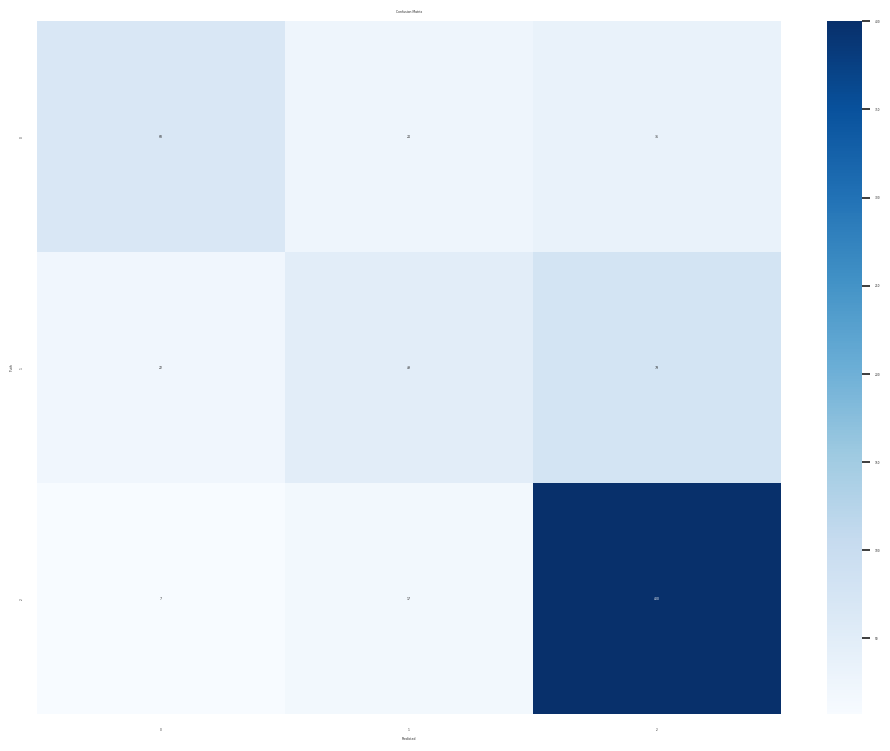

Accuracy Score:  0.7364672364672364
F1-Score:  [0.60444444 0.40833333 0.85197018]
              precision    recall  f1-score   support

           0       0.70      0.53      0.60       128
           1       0.54      0.33      0.41       150
           2       0.78      0.94      0.85       424

    accuracy                           0.74       702
   macro avg       0.67      0.60      0.62       702
weighted avg       0.71      0.74      0.71       702



In [ ]:
# Define a Random Forest model class for training, prediction, evaluation, and confusion matrix plotting

class RandomForestModel:# Initialize the model with training and testing data, and a Random Forest classifier
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.model = RandomForestClassifier()  # Initialize the Random Forest model

    # Train the Random Forest model using the training data
    def train(self):
        self.model.fit(self.X_train, self.y_train)

    # Predict the target variable on the test set
    def predict(self):
        return self.model.predict(self.X_test)

    # Evaluate the model using accuracy, F1-score, and classification report
    def evaluate(self, y_pred):
        accuracy = accuracy_score(self.y_test, y_pred) # Calculate accuracy score
        f1 = f1_score(self.y_test, y_pred, average=None) # Calculate F1-score for each class
        report = classification_report(self.y_test, y_pred) # Generate a detailed classification report (precision, recall, F1-score for each class)
        return accuracy, f1, report

    # Plot the confusion matrix to visualize the model's performance
    def plot_confusion_matrix(self, y_pred):
        cm = confusion_matrix(self.y_test, y_pred) # Compute the confusion matrix
        plt.figure(figsize=(12, 9)) # Create a heatmap to visualize the confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # Annotate with the number of occurrences
        plt.xlabel('Predicted')
        plt.ylabel('Truth')
        plt.title('Confusion Matrix')
        plt.show()


rf_model = RandomForestModel(X_train, y_train, X_test, y_test_classifiers) # Create an instance of the RandomForestModel with training and test data
rf_model.train()
y_pred_rf = rf_model.predict() # Make predictions using the trained model
rf_model.plot_confusion_matrix(y_pred_rf) # Plot the confusion matrix for the predictions
accuracy, f1, report = rf_model.evaluate(y_pred_rf) # Evaluate the model's performance using the predicted values

print("Accuracy Score: ", accuracy)
print("F1-Score: ", f1)
print(report)

### Extreme Gradient Boosting Classifier (XG Boost)

In [ ]:
# Define a class for training, predicting, and evaluating an XGBoost model

class XGBModel: # Initialize the model with training and testing data, and an XGBClassifier

    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.model = XGBClassifier()  # Initialize the XGBoost classifier

    # Train the XGBoost model using the training data
    def train(self):
        self.model.fit(self.X_train, self.y_train)

    # Predict the target variable on the test set
    def predict(self):
        return self.model.predict(self.X_test)

    # Evaluate the model using accuracy, F1-score, and classification report
    def evaluate(self, y_pred):
        accuracy = accuracy_score(self.y_test, y_pred) # Calculate accuracy score
        f1 = f1_score(self.y_test, y_pred, average=None) # Calculate F1-score for each class

        # Generate a detailed classification report (precision, recall, F1-score for each class)
        report = classification_report(self.y_test, y_pred)
        return accuracy, f1, report


xgb_model = XGBModel(X_train, y_train, X_test, y_test_classifiers) # Create an instance of the XGBModel with training and test data
xgb_model.train() # Train the XGBoost model


y_pred_xgb = xgb_model.predict() # Make predictions using the trained model
accuracy, f1, report = xgb_model.evaluate(y_pred_xgb) # Evaluate the model's performance using the predicted values

print("Accuracy Score: ", accuracy)
print("F1-Score: ", f1)
print(report)

Accuracy Score:  0.7606837606837606
F1-Score:  [0.6359447  0.5        0.86615887]
              precision    recall  f1-score   support

           0       0.78      0.54      0.64       128
           1       0.57      0.45      0.50       150
           2       0.80      0.94      0.87       424

    accuracy                           0.76       702
   macro avg       0.72      0.64      0.67       702
weighted avg       0.75      0.76      0.75       702



### LightGBM Classifier

In [ ]:
# Define a LightGBM model class for training, prediction, and evaluation
from lightgbm import LGBMClassifier

class LGBMModel:
    # Initialize the model with training and testing data, and a LightGBM classifier
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.model = LGBMClassifier()  # Initialize the LightGBM model

    # Train the LightGBM model using the training data
    def train(self):
        self.model.fit(self.X_train, self.y_train)

    # Predict the target variable on the test set
    def predict(self):
        return self.model.predict(self.X_test)

    # Evaluate the model using accuracy, F1-score, and classification report
    def evaluate(self, y_pred):
        accuracy = accuracy_score(self.y_test, y_pred) # Calculate accuracy score
        f1 = f1_score(self.y_test, y_pred, average=None) # Calculate F1-score for each class

        # Generate a detailed classification report (precision, recall, F1-score for each class)
        report = classification_report(self.y_test, y_pred)
        return accuracy, f1, report


lgbm_model = LGBMModel(X_train, y_train, X_test, y_test_classifiers) # Create an instance of the LGBMModel with training and test data
lgbm_model.train() # Train the LightGBM model

lgb_predict = lgbm_model.predict() # Make predictions using the trained model

accuracy, f1, report = lgbm_model.evaluate(lgb_predict) # Evaluate the model's performance using the predicted values

print("Accuracy Score: ", accuracy)
print("F1-Score: ", f1)
print(report)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1258
[LightGBM] [Info] Number of data points in the train set: 2807, number of used features: 35
[LightGBM] [Info] Start training from score -1.646452
[LightGBM] [Info] Start training from score -1.613722
[LightGBM] [Info] Start training from score -0.497379
Accuracy Score:  0.7578347578347578
F1-Score:  [0.63013699 0.49264706 0.86746988]
              precision    recall  f1-score   support

           0       0.76      0.54      0.63       128
           1       0.55      0.45      0.49       150
           2       0.81      0.93      0.87       424

    accuracy                           0.76       702
   macro avg       0.71      0.64      0.66       702
weighted avg       0.74      0.76      0.74       702



### CatBoost Classifier

In [ ]:
# Define a CatBoost model class for training, prediction, and evaluation
from catboost import CatBoostClassifier

class CatBoostModel: # Initialize the model with training and testing data, random seed, and number of iterations
    def __init__(self, X_train, y_train, X_test, y_test, random_seed=350, iterations=500):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.model = CatBoostClassifier(random_seed=random_seed, iterations=iterations)  # Initialize the CatBoost model

    # Train the CatBoost model using the training data
    def train(self):
        self.model.fit(self.X_train, self.y_train, verbose=False)  # Train without printing logs (verbose=False)

    # Predict the target variable on the test set
    def predict(self):
        return self.model.predict(self.X_test)  # Return predictions for the test data

    # Evaluate the model using accuracy, F1-score, and classification report
    def evaluate(self, y_pred):
        accuracy = accuracy_score(self.y_test, y_pred) # Calculate accuracy score
        f1 = f1_score(self.y_test, y_pred, average=None) # Calculate F1-score for each class

        # Generate a detailed classification report (precision, recall, F1-score for each class)
        report = classification_report(self.y_test, y_pred)
        return accuracy, f1, report


catboost_model = CatBoostModel(X_train, y_train, X_test, y_test_classifiers) # Create an instance of the CatBoostModel with training and test data
catboost_model.train() # Train the CatBoost model

cat_predict = catboost_model.predict() # Make predictions using the trained model
accuracy, f1, report = catboost_model.evaluate(cat_predict) # Evaluate the model's performance using the predicted values

print("Accuracy Score: ", accuracy)
print("F1-Score: ", f1)
print(report)

Accuracy Score:  0.7507122507122507
F1-Score:  [0.62443439 0.47368421 0.86150491]
              precision    recall  f1-score   support

           0       0.74      0.54      0.62       128
           1       0.54      0.42      0.47       150
           2       0.80      0.93      0.86       424

    accuracy                           0.75       702
   macro avg       0.70      0.63      0.65       702
weighted avg       0.74      0.75      0.74       702



### K-Means Clustering

In [ ]:
X = data.drop('Target', axis=1) #  Drop the target column from the data to get the feature set
y = data['Target'] # Extract the target variable

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

from sklearn.preprocessing import StandardScaler , RobustScaler # Importing StandardScaler and RobustScaler for feature scaling

Standard = StandardScaler() # Initialize StandardScaler for scaling the data

X_train = pd.DataFrame(Standard.fit_transform(X_train),columns=X_train.columns)
X_val = pd.DataFrame(Standard.fit_transform(X_val),columns=X_train.columns)
X_test = pd.DataFrame(Standard.fit_transform(X_test),columns=X_train.columns)

In [ ]:
Robust= RobustScaler() # Initialize RobustScaler to scale data with median and interquartile range, less sensitive to outliers

# Apply RobustScaler to the training, validation, and test dataset
X_train_Robust = pd.DataFrame(Robust.fit_transform(X_train),columns=X_train.columns)
X_val_Robust = pd.DataFrame(Robust.fit_transform(X_val),columns=X_train.columns)
X_test_Robust = pd.DataFrame(Robust.fit_transform(X_test),columns=X_train.columns)

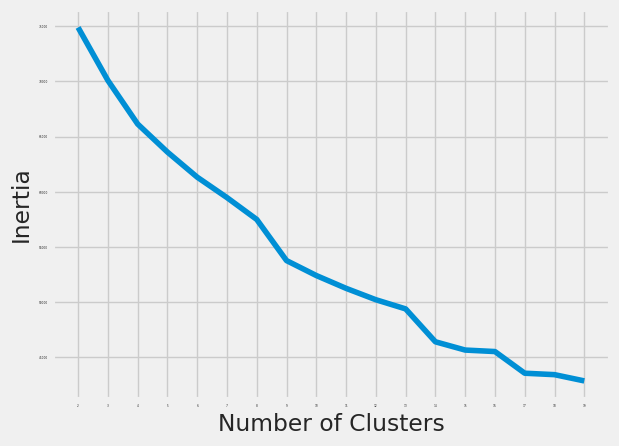

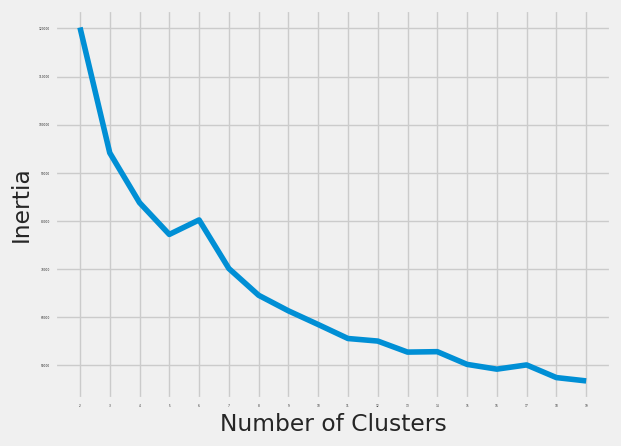

Elbow point: 5


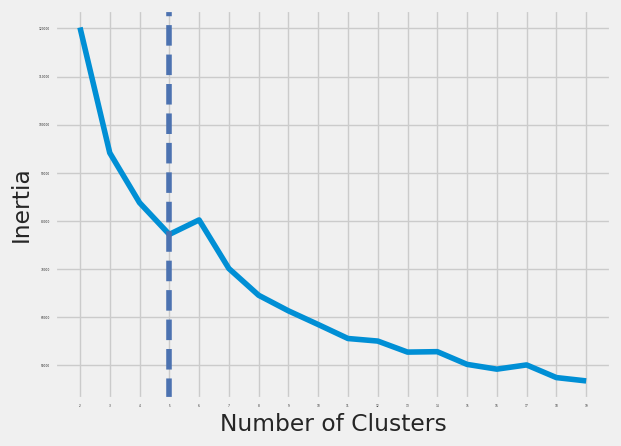

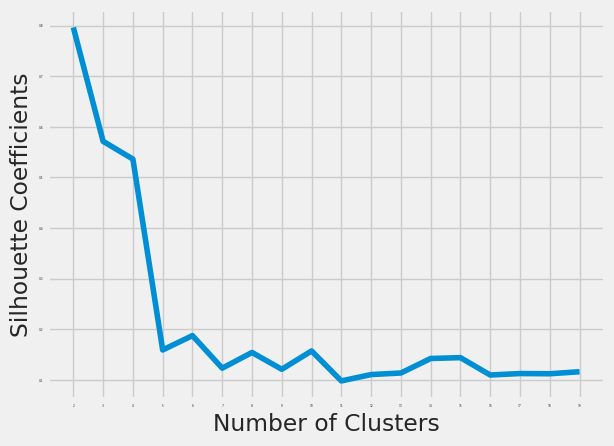

Cluster Labels:
    0
0  0
1  3
2  3
3  3
4  3
Centroids:
              0         1         2          3         4         5   \
0  6.140872e-01  0.169319  0.363864   0.008869  0.438086 -0.182877   
1  2.524123e-01  0.104323  0.589286   0.214858  0.467361 -0.039643   
2  5.551115e-17 -0.010889  0.172414 -20.872011  0.456204  0.180230   
3  4.395240e-02 -0.125164  1.095949   0.333584  0.220015  0.060185   
4  7.329306e-01  0.500000  0.155556  -0.276278  0.867081 -0.160247   
5  6.625824e-01  0.144737  0.562500  -0.164188  0.095869  0.080625   

             6         7         8          9   ...            25        26  \
0  7.591171e-02  0.082427  0.149531   0.199498  ...  3.149289e-01  0.111130   
1 -2.775558e-17  0.039187  0.154412  32.550000  ... -1.942890e-16  0.279108   
2  3.756430e-01 -0.150383 -0.162272   0.000000  ... -5.551115e-17  2.678504   
3  1.405555e-01 -0.034747  0.072411   0.184364  ...  6.231520e-02  0.094593   
4  3.600179e-02  0.130247  0.208279   0.394074  ...  9.

In [ ]:
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from sklearn.cluster import KMeans

# Define a class for clustering and plotting
class KMeansClustering:
    def __init__(self, data, data_robust, range_start=2, range_end=20):
        self.data = data
        self.data_robust = data_robust
        self.range_start = range_start
        self.range_end = range_end

    # Perform KMeans clustering and return inertia for different cluster counts.
    def fit_kmeans(self, data, range_start, range_end):
        inertia = [] # Initialize an empty list to store inertia values
        for k in range(range_start, range_end):
            kmeans = KMeans(n_clusters=k) # Initialize KMeans with k clusters
            kmeans.fit(data) # Fit the model on the data
            inertia.append(kmeans.inertia_)
        return inertia

    # Plot inertia for different cluster counts.
    def plot_inertia(self, inertia, range_start, range_end):
        plt.style.use("fivethirtyeight") # Use a specific style for the plot
        plt.plot(range(range_start, range_end), inertia)
        plt.xticks(range(range_start, range_end)) # Set the x-axis ticks to the range of clusters
        plt.xlabel('Number of Clusters')  # Label for the x-axis
        plt.ylabel('Inertia') # Label for the y-axis
        plt.show()

    # Find the elbow point using the KneeLocator and plot it.
    def find_elbow(self, inertia, range_start, range_end):
        kneedle = KneeLocator(range(range_start, range_end), inertia, curve='convex', direction='decreasing')
        print(f"Elbow point: {kneedle.elbow}")

        plt.style.use("fivethirtyeight")
        plt.plot(range(range_start, range_end), inertia)
        plt.xticks(range(range_start, range_end))
        plt.xlabel('Number of Clusters')
        plt.ylabel('Inertia')
        plt.axvline(x=kneedle.elbow, color='b', label='Elbow', ls='--')
        plt.show()

    # Calculate and plot silhouette scores for different cluster counts.
    def silhouette_scores(self, data, range_start, range_end):
        silhouette_coefficients = [] # Initialize an empty list to store silhouette scores
        for k in range(range_start, range_end):
            kmeans = KMeans(n_clusters=k)  # Initialize KMeans with k clusters
            kmeans.fit(data)
            score = silhouette_score(data, kmeans.labels_) # Calculate silhouette score
            silhouette_coefficients.append(score) # Append the score for the current k

        plt.style.use("fivethirtyeight")
        plt.plot(range(range_start, range_end), silhouette_coefficients)
        plt.xticks(range(range_start, range_end))
        plt.xlabel('Number of Clusters')
        plt.ylabel('Silhouette Coefficients')
        plt.show()

    # Perform clustering on the robust data and return the labels and centroids.
    def perform_clustering(self, n_clusters):
        kmeans = KMeans(n_clusters=n_clusters) # Initialize KMeans with the specified number of clusters
        labels = pd.DataFrame(kmeans.fit_predict(self.data_robust)) # Predict the cluster labels and store them in a DataFrame
        centroids = pd.DataFrame(kmeans.cluster_centers_) # Get the centroids of the clusters
        return labels, centroids

kmeans_clustering = KMeansClustering(X_train, X_train_Robust) # Initialize the KMeansClustering class with training data (X_train and X_train_Robust)

# Step 1: Inertia with Standard PCA
inertia_standard = kmeans_clustering.fit_kmeans(X_train, 2, 20)
kmeans_clustering.plot_inertia(inertia_standard, 2, 20)

# Step 2: Inertia with Robust PCA
inertia_robust = kmeans_clustering.fit_kmeans(X_train_Robust, 2, 20)
kmeans_clustering.plot_inertia(inertia_robust, 2, 20)

# Step 3: Finding the Elbow Point
kmeans_clustering.find_elbow(inertia_robust, 2, 20)

# Step 4: Silhouette Scores
kmeans_clustering.silhouette_scores(X_train_Robust, 2, 20)

# Step 5: Final Clustering with chosen number of clusters (e.g., 6)
labels, centroids = kmeans_clustering.perform_clustering(n_clusters=6)

print("Cluster Labels:\n", labels.head())
print("Centroids:\n", centroids)

## **Comparison**

In [ ]:
# Create a DataFrame to compare the accuracy of different classifiers
Models = pd.DataFrame({'Classifiers':['DecisionTree', 'XGBoost','LightGBM','RandomForest','CatBoost'], 'Accuracy': [accuracy_score(y_test_classifiers, y_pred_dt)*100,accuracy_score(y_test_classifiers, y_pred_xgb)*100,accuracy_score(y_test_classifiers, lgb_predict)*100,accuracy_score(y_test_classifiers, y_pred_rf)*100,accuracy_score(y_test_classifiers, cat_predict)*100]})

<Axes: xlabel='Classifiers', ylabel='Accuracy'>

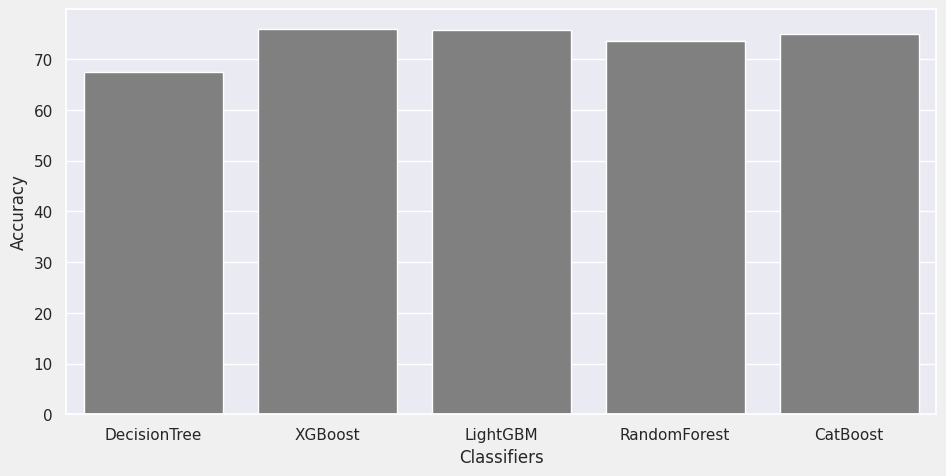

In [ ]:
plt.figure(figsize=(10,5))
sns.set() # Apply seaborn's default styling for the plot
sns.barplot(x=Models['Classifiers'], y=Models['Accuracy'], color="gray") # Create a bar plot with classifiers on the x-axis and accuracy on the y-axis